# 1.0 Project Setup & Imports

Importing all necessary libraries for our project.

In [3]:
import os
from pathlib import Path
import sys
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import databento as db
from scipy import stats
import pyarrow as pa
import pyarrow.parquet as pq

define our main paths 

In [5]:
project_root = r"C:\Users\abond\Desktop\WORK FILES\Systemic\Project 1"
data_path = r"C:\Users\abond\Desktop\WORK FILES\Systemic\Project 1\data\raw\databento\glbx-mdp3-20210524-20260524.ohlcv-1m.dbn"
parquette_path = r"C:\Users\abond\Desktop\WORK FILES\Systemic\Project 1\data\processed\glbx-mdp3-20210524-20260524.ohlcv-1m.parquet"

In [6]:
df = pd.read_parquet(parquette_path)

# 2.0 Load & Inspect Raw Databento Data

## 2.1 Load DBN Store

store = db.DBNStore.from_file(data_path)

**Convert to a DataFrame**

df = store.to_df()

**Convert dbn data to parquet**

df.to_parquet(os.path.join(project_root, "data", "processed", "glbx-mdp3-20210524-20260524.ohlcv-1m.parquet"))

## 2.2 Validate Dataset Structure

**Quick Inspection**

In [8]:
print(df.shape)
df.head()

(9527903, 9)


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2021-05-24 00:00:00+00:00,33,1,18139,-2.2,-2.1,-2.2,-2.1,41,GCM1-GCQ1
2021-05-24 00:00:00+00:00,33,1,152,1886.1,1886.7,1886.1,1886.5,55,GCQ1
2021-05-24 00:00:00+00:00,33,1,100440,1884.2,1884.5,1883.9,1884.0,126,GCM1
2021-05-24 00:00:00+00:00,33,1,23557,-2.1,-2.1,-2.1,-2.1,2,MGCM1-MGCQ1
2021-05-24 00:00:00+00:00,33,1,30106,1886.3,1886.3,1886.3,1886.3,2,MGCQ1


In [9]:
df.columns

Index(['rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low',
       'close', 'volume', 'symbol'],
      dtype='str')

**Data types**

In [10]:
df.dtypes

rtype              uint8
publisher_id      uint16
instrument_id     uint32
open             float64
high             float64
low              float64
close            float64
volume            uint64
symbol               str
dtype: object

**Check for missing entries**

In [11]:
df.isna().sum()

rtype            0
publisher_id     0
instrument_id    0
open             0
high             0
low              0
close            0
volume           0
symbol           0
dtype: int64

**What is the index?**

In [12]:
df.index

DatetimeIndex(['2021-05-24 00:00:00+00:00', '2021-05-24 00:00:00+00:00',
               '2021-05-24 00:00:00+00:00', '2021-05-24 00:00:00+00:00',
               '2021-05-24 00:00:00+00:00', '2021-05-24 00:00:00+00:00',
               '2021-05-24 00:01:00+00:00', '2021-05-24 00:01:00+00:00',
               '2021-05-24 00:01:00+00:00', '2021-05-24 00:01:00+00:00',
               ...
               '2026-05-22 20:58:00+00:00', '2026-05-22 20:58:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00',
               '2026-05-22 20:59:00+00:00', '2026-05-22 20:59:00+00:00'],
              dtype='datetime64[ns, UTC]', name='ts_event', length=9527903, freq=None)

**Data date range**

In [13]:
df.index.min(), df.index.max()

(Timestamp('2021-05-24 00:00:00+0000', tz='UTC'),
 Timestamp('2026-05-22 20:59:00+0000', tz='UTC'))

**Are timestamps sorted?**

In [14]:
df.index.is_monotonic_increasing

True

**Check for duplicated enties**

In [15]:
df.duplicated().sum()

np.int64(3537591)

**Convert time from utc to New York time**

In [16]:
df.index.tz_convert("America/New_York")

DatetimeIndex(['2021-05-23 20:00:00-04:00', '2021-05-23 20:00:00-04:00',
               '2021-05-23 20:00:00-04:00', '2021-05-23 20:00:00-04:00',
               '2021-05-23 20:00:00-04:00', '2021-05-23 20:00:00-04:00',
               '2021-05-23 20:01:00-04:00', '2021-05-23 20:01:00-04:00',
               '2021-05-23 20:01:00-04:00', '2021-05-23 20:01:00-04:00',
               ...
               '2026-05-22 16:58:00-04:00', '2026-05-22 16:58:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00',
               '2026-05-22 16:59:00-04:00', '2026-05-22 16:59:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='ts_event', length=9527903, freq=None)

**Separate the data by the symbols**

In [17]:
gc = df[df["symbol"].str.startswith("GC") & ~df["symbol"].str.contains("-")]

mgc = df[df["symbol"].str.startswith("MGC") & ~df["symbol"].str.contains("-")]

spreads = df[df["symbol"].str.contains("-")]

In [18]:
gc.head()

,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2021-05-24 00:00:00+00:00,33,1,152,1886.1,1886.7,1886.1,1886.5,55,GCQ1
2021-05-24 00:00:00+00:00,33,1,100440,1884.2,1884.5,1883.9,1884.0,126,GCM1
2021-05-24 00:01:00+00:00,33,1,152,1886.0,1886.0,1885.4,1885.7,6,GCQ1
2021-05-24 00:01:00+00:00,33,1,51659,1889.0,1889.0,1889.0,1889.0,1,GCZ1
2021-05-24 00:01:00+00:00,33,1,100440,1884.1,1884.1,1882.9,1883.3,116,GCM1


**Get all GC symbols**

In [19]:
gc_symbols = sorted(df[df["symbol"].str.startswith("GC") & ~df["symbol"].str.contains("-")]["symbol"].unique())
gc_symbols

['GCF2',
 'GCF3',
 'GCF4',
 'GCF5',
 'GCF6',
 'GCF7',
 'GCF8',
 'GCG2',
 'GCG3',
 'GCG4',
 'GCG5',
 'GCG6',
 'GCG7',
 'GCG8',
 'GCH2',
 'GCH3',
 'GCH4',
 'GCH5',
 'GCH6',
 'GCH7',
 'GCH8',
 'GCJ2',
 'GCJ3',
 'GCJ4',
 'GCJ5',
 'GCJ6',
 'GCJ7',
 'GCJ8',
 'GCK1',
 'GCK2',
 'GCK3',
 'GCK4',
 'GCK5',
 'GCK6',
 'GCM1',
 'GCM2',
 'GCM3',
 'GCM4',
 'GCM5',
 'GCM6',
 'GCM7',
 'GCM8',
 'GCM9',
 'GCN1',
 'GCN2',
 'GCN3',
 'GCN4',
 'GCN5',
 'GCN6',
 'GCQ1',
 'GCQ2',
 'GCQ3',
 'GCQ4',
 'GCQ5',
 'GCQ6',
 'GCQ7',
 'GCU1',
 'GCU2',
 'GCU3',
 'GCU4',
 'GCU5',
 'GCU6',
 'GCV1',
 'GCV2',
 'GCV3',
 'GCV4',
 'GCV5',
 'GCV6',
 'GCV7',
 'GCX1',
 'GCX2',
 'GCX3',
 'GCX4',
 'GCX5',
 'GCX6',
 'GCX7',
 'GCZ1',
 'GCZ2',
 'GCZ3',
 'GCZ4',
 'GCZ5',
 'GCZ6',
 'GCZ7',
 'GCZ8',
 'GCZ9']

In [20]:
# extract month code (1 letter after GC)
gc["contract_month"] = gc["symbol"].str.extract(r"GC([A-Z])")
gc["contract_month"].unique()

<ArrowStringArray>
['Q', 'M', 'Z', 'N', 'V', 'G', 'K', 'J', 'U', 'X', 'F', 'H']
Length: 12, dtype: str

In [21]:
month_groups = {}

for month, group in gc.groupby("contract_month"):
    month_groups[month] = group

In [22]:
month_groups["F"]

,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,contract_month
ts_event,,,,,,,,,,
2021-10-29 12:33:00+00:00,33,1,552,1789.3,1789.3,1789.3,1789.3,1,GCF2,F
2021-10-29 12:54:00+00:00,33,1,552,1779.0,1779.0,1779.0,1779.0,1,GCF2,F
2021-10-29 13:34:00+00:00,33,1,552,1777.8,1777.8,1777.8,1777.8,1,GCF2,F
2021-10-29 13:56:00+00:00,33,1,552,1777.6,1778.3,1777.6,1778.3,2,GCF2,F
2021-10-29 14:04:00+00:00,33,1,552,1776.9,1777.3,1776.9,1777.3,2,GCF2,F
...,...,...,...,...,...,...,...,...,...,...
2026-05-20 14:58:00+00:00,33,1,42024763,4655.8,4655.8,4655.8,4655.8,1,GCF7,F
2026-05-20 15:22:00+00:00,33,1,42024763,4663.9,4663.9,4663.9,4663.9,1,GCF7,F
2026-05-21 18:05:00+00:00,33,1,42024763,4666.7,4666.7,4666.7,4666.7,1,GCF7,F


# 3.0 E.D.A


## 3.1 Data Quality Assessment

### 3.1.1 Reload Parquet Validation

In [23]:
parquet_path = os.path.join(
    project_root,
    "data",
    "processed",
    "glbx-mdp3-20210524-20260524.ohlcv-1m.parquet",
)

# From this point forward, df is the Parquet-backed research dataset.
df = pd.read_parquet(parquet_path)

print(df.shape)
df.head()


(9527903, 9)


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2021-05-24 00:00:00+00:00,33,1,18139,-2.2,-2.1,-2.2,-2.1,41,GCM1-GCQ1
2021-05-24 00:00:00+00:00,33,1,152,1886.1,1886.7,1886.1,1886.5,55,GCQ1
2021-05-24 00:00:00+00:00,33,1,100440,1884.2,1884.5,1883.9,1884.0,126,GCM1
2021-05-24 00:00:00+00:00,33,1,23557,-2.1,-2.1,-2.1,-2.1,2,MGCM1-MGCQ1
2021-05-24 00:00:00+00:00,33,1,30106,1886.3,1886.3,1886.3,1886.3,2,MGCQ1


### 3.1.2 Dataset Shape & Coverage


In [24]:
dataset_coverage = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "start_utc": df.index.min(),
    "end_utc": df.index.max(),
    "unique_timestamps": df.index.nunique(),
    "unique_symbols": df["symbol"].nunique(),
    "unique_instrument_ids": df["instrument_id"].nunique(),
})

dataset_coverage


rows                                       9527903
columns                                          9
start_utc                2021-05-24 00:00:00+00:00
end_utc                  2026-05-22 20:59:00+00:00
unique_timestamps                          1773177
unique_symbols                                1034
unique_instrument_ids                         1032
dtype: object

In [25]:
symbol_str = df["symbol"].astype(str)

# Keep the same separation logic used above, but make explicit copies for EDA.
gc = df[symbol_str.str.startswith("GC") & ~symbol_str.str.contains("-", regex=False)].copy()
mgc = df[symbol_str.str.startswith("MGC") & ~symbol_str.str.contains("-", regex=False)].copy()
spreads = df[symbol_str.str.contains("-", regex=False)].copy()

symbol_coverage = pd.DataFrame({
    "rows": [len(gc), len(mgc), len(spreads), len(df)],
    "symbols": [gc["symbol"].nunique(), mgc["symbol"].nunique(), spreads["symbol"].nunique(), df["symbol"].nunique()],
}, index=["GC outrights", "MGC outrights", "Spreads", "Total"])

symbol_coverage


,rows,symbols
GC outrights,3422034,85
MGC outrights,2934871,41
Spreads,3170998,908
Total,9527903,1034


### 3.1.3 Missing Values


In [26]:
missing_values = df.isna().sum().to_frame("missing_count")
missing_values["missing_pct"] = (missing_values["missing_count"] / len(df)) * 100
missing_values


,missing_count,missing_pct
rtype,0,0.0
publisher_id,0,0.0
instrument_id,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0
symbol,0,0.0


### 3.1.4 Duplicate Records

Because this is a multi-instrument dataset, duplicate checks must include the timestamp. Checking `df.duplicated()` alone ignores the DatetimeIndex and can create a false alarm.


In [27]:
df_with_timestamp = df.reset_index()

duplicate_checks = pd.Series({
    "duplicate_full_records_including_timestamp": df_with_timestamp.duplicated().sum(),
    "duplicate_timestamp_symbol": df_with_timestamp.duplicated(["ts_event", "symbol"]).sum(),
    "duplicate_timestamp_instrument_id": df_with_timestamp.duplicated(["ts_event", "instrument_id"]).sum(),
    "duplicate_rows_ignoring_timestamp": df.duplicated().sum(),
})

duplicate_checks


duplicate_full_records_including_timestamp          0
duplicate_timestamp_symbol                          0
duplicate_timestamp_instrument_id                   0
duplicate_rows_ignoring_timestamp             3537591
dtype: int64

### 3.1.5 Timestamp Integrity


In [28]:
timestamp_integrity = pd.Series({
    "timezone": str(df.index.tz),
    "is_monotonic_increasing": df.index.is_monotonic_increasing,
    "unique_timestamps": df.index.nunique(),
    "duplicate_index_timestamps": df.index.duplicated().sum(),
    "non_minute_aligned_timestamps": ((df.index.second != 0) | (df.index.microsecond != 0) | (df.index.nanosecond != 0)).sum(),
})

timestamp_integrity


timezone                             UTC
is_monotonic_increasing             True
unique_timestamps                1773177
duplicate_index_timestamps       7754726
non_minute_aligned_timestamps          0
dtype: object

In [29]:
price_cols = ["open", "high", "low", "close"]
outright_mask = ~symbol_str.str.contains("-", regex=False)
gc_mgc_outright_mask = (symbol_str.str.startswith("GC") | symbol_str.str.startswith("MGC")) & outright_mask

bad_ohlc = (
    (df["high"] < df[["open", "close", "low"]].max(axis=1))
    | (df["low"] > df[["open", "close", "high"]].min(axis=1))
)

negative_prices = (df[price_cols] <= 0).any(axis=1)

price_integrity = pd.Series({
    "bad_ohlc_rows_all_symbols": bad_ohlc.sum(),
    "bad_ohlc_rows_gc_mgc_outrights": bad_ohlc[gc_mgc_outright_mask].sum(),
    "negative_price_rows_all_symbols": negative_prices.sum(),
    "negative_price_rows_gc_mgc_outrights": negative_prices[gc_mgc_outright_mask].sum(),
    "zero_volume_rows": (df["volume"] == 0).sum(),
})

price_integrity


bad_ohlc_rows_all_symbols                     0
bad_ohlc_rows_gc_mgc_outrights                0
negative_price_rows_all_symbols         3170744
negative_price_rows_gc_mgc_outrights          0
zero_volume_rows                              0
dtype: int64

### 3.1.6 Trading Session Gaps

This first pass checks gaps in the global timestamp set. Later, gap analysis should be repeated on the selected active/front-month contract because individual contracts naturally become inactive outside their liquid trading window.


In [30]:
unique_timestamps = df.index.drop_duplicates().sort_values()
timestamp_diffs = unique_timestamps.to_series().diff().dropna()
session_gaps = timestamp_diffs[timestamp_diffs > pd.Timedelta(minutes=1)]

gap_summary = pd.Series({
    "global_gaps_over_1_minute": len(session_gaps),
    "largest_gap": session_gaps.max(),
    "first_gap_end": session_gaps.index.min(),
    "last_gap_end": session_gaps.index.max(),
})

gap_summary


global_gaps_over_1_minute                         2021
largest_gap                            3 days 01:01:00
first_gap_end                2021-05-24 22:00:00+00:00
last_gap_end                 2026-05-21 22:00:00+00:00
dtype: object

In [31]:
session_gaps.value_counts().head(10).to_frame("count")


,count
ts_event,
0 days 01:01:00,993
0 days 00:02:00,716
2 days 01:01:00,234
0 days 03:31:00,29
0 days 00:03:00,12
3 days 01:01:00,10
2 days 02:01:00,5
2 days 00:01:00,5
0 days 05:01:00,4


In [32]:
session_gaps.sort_values(ascending=False).head(10).to_frame("gap_length")


,gap_length
ts_event,
2023-12-25 23:00:00+00:00,3 days 01:01:00
2025-04-20 22:00:00+00:00,3 days 01:01:00
2023-04-09 22:00:00+00:00,3 days 01:01:00
2024-01-01 23:00:00+00:00,3 days 01:01:00
2022-04-17 22:00:00+00:00,3 days 01:01:00
2026-04-05 22:00:00+00:00,3 days 01:01:00
2021-12-26 23:00:00+00:00,3 days 01:01:00
2022-12-26 23:00:00+00:00,3 days 01:01:00
2024-03-31 22:00:00+00:00,3 days 01:01:00


### 3.1.7 Data Quality Assessment Summary


In [33]:
quality_summary = pd.Series({
    "parquet_reload_ok": True,
    "missing_values": df.isna().sum().sum(),
    "duplicate_timestamp_symbol": duplicate_checks["duplicate_timestamp_symbol"],
    "duplicate_timestamp_instrument_id": duplicate_checks["duplicate_timestamp_instrument_id"],
    "timestamps_sorted": df.index.is_monotonic_increasing,
    "timestamps_minute_aligned": timestamp_integrity["non_minute_aligned_timestamps"] == 0,
    "gc_mgc_outright_negative_prices": price_integrity["negative_price_rows_gc_mgc_outrights"],
    "session_gaps_need_calendar_handling": True,
})

quality_summary


parquet_reload_ok                      True
missing_values                            0
duplicate_timestamp_symbol                0
duplicate_timestamp_instrument_id         0
timestamps_sorted                      True
timestamps_minute_aligned              True
gc_mgc_outright_negative_prices           0
session_gaps_need_calendar_handling    True
dtype: object

**Conclusion**

The processed Parquet dataset is clean enough to proceed with EDA. The main caveat is structural: the dataset contains both outright futures and spreads, and session gaps are normal for CME futures. For directional research, continue using outright GC/MGC contracts and handle market sessions explicitly before calculating returns or testing signals.

**Next:** 3.2 Contract Structure Analysis.


# 3.1 Data Quality Assessment

## 3.1.1 Reload Parquet Validation

The Parquet file loaded successfully with a shape of:

```text
(9,527,903, 9)
```

This indicates that the dataset contains approximately **9.5 million 1-minute bars** across **9 columns**. Inspection of the first few rows confirmed the presence of both outright futures contracts (e.g., `GCQ1`, `GCM1`, `MGCQ1`) and calendar spread instruments (e.g., `GCM1-GCQ1`).

Some rows displayed negative price values; however, these correspond to spread instruments and not outright futures contracts. Therefore, the negative values do not indicate data quality issues.

### Conclusion

The Parquet conversion and reload process was successful, and the dataset appears intact and ready for further analysis.

---

## 3.1.2 Dataset Shape & Coverage

### Results

```text
Rows:                  9,527,903
Columns:               9
Start UTC:             2021-05-24
End UTC:               2026-05-22
Unique Timestamps:     1,773,177
Unique Symbols:        1,034
Unique Instrument IDs: 1,032
```

The dataset spans approximately **five years** of CME Gold Futures market activity. The large number of symbols is expected because each futures contract month and spread instrument is represented by a unique symbol.

### Symbol Breakdown

```text
GC Outrights:   3,422,034 rows, 85 symbols
MGC Outrights:  2,934,871 rows, 41 symbols
Spreads:        3,170,998 rows, 908 symbols
```

The majority of symbols are spread instruments, while outright GC and MGC contracts account for the primary directional trading instruments.

### Conclusion

The dataset provides extensive historical coverage suitable for strategy research. Since the project focuses on directional futures trading, analysis should initially concentrate on GC and MGC outright contracts rather than spread instruments.

---

## 3.1.3 Missing Values

### Results

All columns returned:

```text
Missing Count = 0
Missing Percentage = 0.0%
```

No missing values were detected in any field, including:

* Open
* High
* Low
* Close
* Volume
* Symbol
* Instrument ID

### Conclusion

The dataset contains no missing observations and therefore requires no imputation or missing-value treatment at this stage.

---

## 3.1.4 Duplicate Records

### Results

```text
Duplicate Full Records Including Timestamp: 0
Duplicate Timestamp + Symbol:               0
Duplicate Timestamp + Instrument ID:        0
Duplicate Rows Ignoring Timestamp:    3,537,591
```

No true duplicate market records were identified.

The large number of duplicates reported when ignoring timestamps occurs because many observations share identical OHLCV values across different timestamps. Since the timestamp index is excluded from that calculation, these observations are incorrectly flagged as duplicates despite representing distinct market events.

The more relevant duplicate checks are:

* Timestamp + Symbol
* Timestamp + Instrument ID

Both returned zero duplicate records.

### Conclusion

The dataset contains no genuine duplicate observations and maintains record-level uniqueness.

---

## 3.1.5 Timestamp Integrity

### Results

```text
Timezone: UTC
Is Monotonic Increasing: True
Unique Timestamps: 1,773,177
Duplicate Index Timestamps: 7,754,726
Non-Minute-Aligned Timestamps: 0
```

Timestamps are:

* Timezone-aware (UTC)
* Chronologically sorted
* Consistently aligned to 1-minute intervals

The large number of duplicate timestamps is expected because multiple contracts trade simultaneously during the same minute.

### Price Integrity Results

```text
Bad OHLC Rows (All Symbols):               0
Bad OHLC Rows (GC/MGC Outrights):          0
Negative Price Rows (All Symbols):   3,170,744
Negative Price Rows (GC/MGC Outrights):    0
Zero Volume Rows:                          0
```

No violations of OHLC structure were detected. All negative price observations originate from spread instruments, while outright GC and MGC contracts contain no negative prices.

### Conclusion

Timestamp quality is excellent, and the OHLC data is internally consistent. The outright futures contracts appear clean and reliable for subsequent analysis.

---

## 3.1.6 Trading Session Gaps

### Results

```text
Global Gaps Greater Than 1 Minute: 2,021
Largest Gap: 3 days 01:01:00
```

Most common gap durations:

```text
1 hour 1 minute:          993
2 minutes:                716
2 days 1 hour 1 minute:   234
```

These gaps are largely expected and reflect:

* CME daily maintenance windows
* Weekend market closures
* Exchange holidays
* Reduced trading schedules

### Conclusion

Observed gaps are consistent with futures market trading schedules rather than data quality problems. Future analysis should incorporate session-aware handling and avoid blindly forward-filling across market closures.

---

## 3.1.7 Summary

### Final Validation Results

```text
parquet_reload_ok: True
missing_values: 0
duplicate_timestamp_symbol: 0
duplicate_timestamp_instrument_id: 0
timestamps_sorted: True
timestamps_minute_aligned: True
gc_mgc_outright_negative_prices: 0
session_gaps_need_calendar_handling: True
```

### Overall Assessment

The dataset is of high quality and suitable for quantitative research. No significant issues were identified regarding missing data, duplicate records, timestamp integrity, or outright futures pricing.

The primary challenges moving forward are not related to vendor data quality but rather to correctly handling futures-specific market structure, including:

* Contract selection
* Front-month identification
* Contract rollovers
* Liquidity transitions
* Trading session boundaries
* Market closure gaps

These topics will be addressed in subsequent stages of the exploratory data analysis.


## 3.2 Contract Structure Analysis


This section studies the structure of the GC and MGC outright contracts in the dataset.

The goal is to understand what contracts exist, which delivery months dominate, how long contracts remain active, and where liquidity tends to concentrate before we build any continuous/front-month series.


### 3.2.1 Contract Inventory


In [34]:
# Rebuild outright universe explicitly so this section can be run independently after 3.1.
symbol_str = df["symbol"].astype(str)
outright_mask = ~symbol_str.str.contains("-", regex=False)

gc = df[symbol_str.str.startswith("GC") & outright_mask].copy()
mgc = df[symbol_str.str.startswith("MGC") & outright_mask].copy()
spreads = df[~outright_mask].copy()

outrights = pd.concat([
    gc.assign(product="GC"),
    mgc.assign(product="MGC"),
]).sort_index()

contract_inventory = (
    outrights
    .reset_index()
    .groupby(["product", "symbol"], observed=True)
    .agg(
        first_bar=("ts_event", "min"),
        last_bar=("ts_event", "max"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        max_volume_bar=("volume", "max"),
    )
    .sort_values(["product", "first_bar", "symbol"])
)

contract_inventory.head(20)


first_bar                  last_bar    bars  \
product symbol                                                               
GC      GCM1   2021-05-24 00:00:00+00:00 2021-06-25 14:28:00+00:00    6168   
        GCQ1   2021-05-24 00:00:00+00:00 2021-08-27 14:39:00+00:00   67712   
        GCZ1   2021-05-24 00:01:00+00:00 2021-12-29 15:29:00+00:00  144263   
        GCN1   2021-05-24 00:09:00+00:00 2021-07-27 13:40:00+00:00    6509   
        GCV1   2021-05-24 00:18:00+00:00 2021-10-27 14:02:00+00:00   36807   
        GCG2   2021-05-24 01:12:00+00:00 2022-02-24 15:30:00+00:00   94287   
        GCZ2   2021-05-24 10:26:00+00:00 2022-12-28 14:04:00+00:00  162269   
        GCK1   2021-05-24 12:05:00+00:00 2021-05-25 13:46:00+00:00       6   
        GCJ2   2021-05-24 12:07:00+00:00 2022-04-27 15:53:00+00:00   94464   
        GCM2   2021-05-24 15:45:00+00:00 2022-06-28 16:27:00+00:00  103478   
        GCV2   2021-05-25 11:05:00+00:00 2022-10-26 13:40:00+00:00   46180   
        GCZ4   2021-05-26 02:38:00+00:00 2024-12-27 18:03:00+00:00  164339   
        GCQ2   2021-05-26 14:05:00+00:00 2022-08-29 16:55:00+00:00   95636   
        GCU1   2021-06-30 06:36:00+00:00 2021-09-28 13:43:00+00:00    7277   
        GCM3   2021-08-06 13:13:00+00:00 2023-06-27 19:24:00+00:00  103771   
        GCZ3   2021-08-10 13:29:00+00:00 2023-12-27 10:28:00+00:00  156743   
        GCX1   2021-09-01 04:19:00+00:00 2021-11-25 14:41:00+00:00    3613   
        GCJ3   2021-10-13 19:09:00+00:00 2023-04-26 16:55:00+00:00   95854   
        GCM4   2021-10-18 12:32:00+00:00 2024-06-26 13:22:00+00:00  111515   
        GCF2   2021-10-29 12:33:00+00:00 2022-01-25 13:51:00+00:00    5918   

                total_volume  avg_volume_per_bar  max_volume_bar  
product symbol                                                    
GC      GCM1          467597           75.810149            5911  
        GCQ1         8188874          120.936821            6604  
        GCZ1        14685478          101.796566            7136  
        GCN1           23873            3.667691             159  
        GCV1          202282            5.495748             296  
        GCG2         6468990           68.609564            7431  
        GCZ2        14285277           88.034541            6571  
        GCK1              10            1.666667               5  
        GCJ2         8060349           85.327204            5676  
        GCM2         6381702           61.672066            3804  
        GCV2          242926            5.260416             355  
        GCZ4        15001264           91.282434            5549  
        GCQ2         6308489           65.963539            5996  
        GCU1           25536            3.509138             231  
        GCM3         8119961           78.248846            6141  
        GCZ3        14331153           91.430896            8602  
        GCX1           14173            3.922779             160  
        GCJ3         8254394           86.114236            6773  
        GCM4        10215294           91.604663            5707  
        GCF2           19519            3.298243             123

In [35]:
inventory_summary = contract_inventory.groupby(level="product").agg(
    contracts=("bars", "size"),
    total_bars=("bars", "sum"),
    total_volume=("total_volume", "sum"),
    first_bar=("first_bar", "min"),
    last_bar=("last_bar", "max"),
)

inventory_summary


,contracts,total_bars,total_volume,first_bar,last_bar
product,,,,,
GC,85,3422034,230863662,2021-05-24 00:00:00+00:00,2026-05-22 20:59:00+00:00
MGC,41,2934871,186643698,2021-05-24 00:00:00+00:00,2026-05-22 20:59:00+00:00


### 3.2.2 Contract Month Distribution


In [36]:
month_code_map = {
    "F": "Jan",
    "G": "Feb",
    "H": "Mar",
    "J": "Apr",
    "K": "May",
    "M": "Jun",
    "N": "Jul",
    "Q": "Aug",
    "U": "Sep",
    "V": "Oct",
    "X": "Nov",
    "Z": "Dec",
}

# MGC starts with three letters, GC starts with two; extract month/year safely by product.
contract_inventory_reset = contract_inventory.reset_index()
contract_inventory_reset["month_code"] = np.where(
    contract_inventory_reset["product"].eq("MGC"),
    contract_inventory_reset["symbol"].str.extract(r"^MGC([FGHJKMNQUVXZ])", expand=False),
    contract_inventory_reset["symbol"].str.extract(r"^GC([FGHJKMNQUVXZ])", expand=False),
)
contract_inventory_reset["month"] = contract_inventory_reset["month_code"].map(month_code_map)
contract_inventory_reset["contract_year_code"] = np.where(
    contract_inventory_reset["product"].eq("MGC"),
    contract_inventory_reset["symbol"].str.extract(r"^MGC[FGHJKMNQUVXZ](\d+)$", expand=False),
    contract_inventory_reset["symbol"].str.extract(r"^GC[FGHJKMNQUVXZ](\d+)$", expand=False),
)

month_distribution = (
    contract_inventory_reset
    .groupby(["product", "month_code", "month"], observed=True)
    .agg(
        contracts=("symbol", "nunique"),
        bars=("bars", "sum"),
        total_volume=("total_volume", "sum"),
        avg_volume_per_contract=("total_volume", "mean"),
    )
    .sort_values(["product", "total_volume"], ascending=[True, False])
)

month_distribution


contracts    bars  total_volume  \
product month_code month                                    
GC      Z          Dec            9  808664      77781354   
        M          Jun            9  546977      40185944   
        J          Apr            7  496768      38547397   
        Q          Aug            7  524770      36884757   
        G          Feb            7  507396      35040425   
        V          Oct            7  260032       1464974   
        H          Mar            7   63203        253104   
        K          May            6   50785        165475   
        U          Sep            6   46373        162774   
        N          Jul            6   46010        145842   
        F          Jan            7   43218        137208   
        X          Nov            7   27838         94408   
MGC     Z          Dec            7  704625      55898524   
        M          Jun            7  494834      39139956   
        J          Apr            6  461933      38958423   
        G          Feb            7  476058      30294668   
        Q          Aug            7  491510      20627121   
        V          Oct            7  305911       1725006   

                          avg_volume_per_contract  
product month_code month                           
GC      Z          Dec               8.642373e+06  
        M          Jun               4.465105e+06  
        J          Apr               5.506771e+06  
        Q          Aug               5.269251e+06  
        G          Feb               5.005775e+06  
        V          Oct               2.092820e+05  
        H          Mar               3.615771e+04  
        K          May               2.757917e+04  
        U          Sep               2.712900e+04  
        N          Jul               2.430700e+04  
        F          Jan               1.960114e+04  
        X          Nov               1.348686e+04  
MGC     Z          Dec               7.985503e+06  
        M          Jun               5.591422e+06  
        J          Apr               6.493070e+06  
        G          Feb               4.327810e+06  
        Q          Aug               2.946732e+06  
        V          Oct               2.464294e+05

In [37]:
month_volume_pivot = (
    month_distribution
    .reset_index()
    .pivot(index="month_code", columns="product", values="total_volume")
    .reindex(list(month_code_map.keys()))
)

month_volume_pivot


product,GC,MGC
month_code,,
F,137208.0,NaN
G,35040425.0,30294668.0
H,253104.0,NaN
J,38547397.0,38958423.0
K,165475.0,NaN
M,40185944.0,39139956.0
N,145842.0,NaN
Q,36884757.0,20627121.0
U,162774.0,NaN


### 3.2.3 Contract Lifespans


In [38]:
contract_inventory_reset["lifespan_days"] = (
    contract_inventory_reset["last_bar"] - contract_inventory_reset["first_bar"]
).dt.total_seconds() / (60 * 60 * 24)

active_days_by_contract = (
    outrights
    .reset_index()
    .assign(trade_date=lambda x: x["ts_event"].dt.date)
    .groupby(["product", "symbol"], observed=True)["trade_date"]
    .nunique()
    .rename("active_days")
    .reset_index()
)

contract_inventory_reset = contract_inventory_reset.merge(
    active_days_by_contract,
    on=["product", "symbol"],
    how="left",
)

lifespan_summary = contract_inventory_reset.groupby("product").agg(
    contracts=("symbol", "nunique"),
    median_lifespan_days=("lifespan_days", "median"),
    mean_lifespan_days=("lifespan_days", "mean"),
    max_lifespan_days=("lifespan_days", "max"),
    median_active_days=("active_days", "median"),
    mean_active_days=("active_days", "mean"),
    max_active_days=("active_days", "max"),
)

lifespan_summary


,contracts,median_lifespan_days,mean_lifespan_days,max_lifespan_days,median_active_days,mean_active_days,max_active_days
product,,,,,,,
GC,85,271.323611,336.673693,1600.277083,116.0,177.152941,545
MGC,41,544.098611,473.372696,724.882639,332.0,283.975610,460


In [39]:
top_contract_lifespans = (
    contract_inventory_reset
    .sort_values(["product", "total_volume"], ascending=[True, False])
    [["product", "symbol", "month_code", "month", "first_bar", "last_bar", "lifespan_days", "active_days", "bars", "total_volume"]]
    .head(25)
)

top_contract_lifespans


,product,symbol,month_code,month,first_bar,last_bar,lifespan_days,active_days,bars,total_volume
22,GC,GCZ5,Z,Dec,2022-01-03 13:44:00+00:00,2025-12-29 14:34:00+00:00,1456.034722,513,158853,19414779
11,GC,GCZ4,Z,Dec,2021-05-26 02:38:00+00:00,2024-12-27 18:03:00+00:00,1311.642361,545,164339,15001264
2,GC,GCZ1,Z,Dec,2021-05-24 00:01:00+00:00,2021-12-29 15:29:00+00:00,219.644444,185,144263,14685478
15,GC,GCZ3,Z,Dec,2021-08-10 13:29:00+00:00,2023-12-27 10:28:00+00:00,868.874306,460,156743,14331153
6,GC,GCZ2,Z,Dec,2021-05-24 10:26:00+00:00,2022-12-28 14:04:00+00:00,583.151389,463,162269,14285277
18,GC,GCM4,M,Jun,2021-10-18 12:32:00+00:00,2024-06-26 13:22:00+00:00,982.034722,360,111515,10215294
37,GC,GCM5,M,Jun,2023-03-20 14:12:00+00:00,2025-06-26 00:13:00+00:00,828.417361,375,107447,9742101
51,GC,GCG6,G,Feb,2024-08-20 12:24:00+00:00,2026-02-25 11:41:00+00:00,553.970139,340,106360,8836593
17,GC,GCJ3,J,Apr,2021-10-13 19:09:00+00:00,2023-04-26 16:55:00+00:00,559.906944,351,95854,8254394
1,GC,GCQ1,Q,Aug,2021-05-24 00:00:00+00:00,2021-08-27 14:39:00+00:00,95.610417,82,67712,8188874


### 3.2.4 Contract Activity Timeline


In [40]:
daily_contract_activity = (
    outrights
    .reset_index()
    .assign(trade_date=lambda x: x["ts_event"].dt.date)
    .groupby(["trade_date", "product"], observed=True)
    .agg(
        active_contracts=("symbol", "nunique"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
    )
    .reset_index()
)

activity_timeline_summary = daily_contract_activity.groupby("product").agg(
    days=("trade_date", "nunique"),
    median_active_contracts=("active_contracts", "median"),
    mean_active_contracts=("active_contracts", "mean"),
    max_active_contracts=("active_contracts", "max"),
    median_daily_volume=("total_volume", "median"),
    max_daily_volume=("total_volume", "max"),
)

activity_timeline_summary


,days,median_active_contracts,mean_active_contracts,max_active_contracts,median_daily_volume,max_daily_volume
product,,,,,,
GC,1555,9.0,9.683601,22,156668.0,537850
MGC,1555,7.0,7.487460,12,58888.0,1536127


In [41]:
# Monthly view keeps the timeline compact enough for inspection.
monthly_contract_activity = (
    outrights
    .reset_index()
    .assign(month=lambda x: x["ts_event"].dt.strftime("%Y-%m"))
    .groupby(["month", "product"], observed=True)
    .agg(
        active_contracts=("symbol", "nunique"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
    )
    .reset_index()
)

monthly_contract_activity.tail(24)


,month,product,active_contracts,bars,total_volume
98,2025-06,GC,17,55679,3801062
99,2025-06,MGC,11,51227,5169326
100,2025-07,GC,22,73242,3755024
101,2025-07,MGC,9,66946,4393642
102,2025-08,GC,22,62719,3522856
103,2025-08,MGC,10,61844,3980816
104,2025-09,GC,22,67049,4797306
105,2025-09,MGC,11,72518,6557028
106,2025-10,GC,24,73856,7598158
107,2025-10,MGC,12,75163,16143023


### 3.2.5 Major vs Minor Delivery Months


In [42]:
# Use observed volume to classify major vs minor months instead of relying only on convention.
major_month_count = 5

month_rankings = month_distribution.reset_index().copy()
month_rankings["volume_rank_within_product"] = month_rankings.groupby("product")["total_volume"].rank(
    method="first",
    ascending=False,
)
month_rankings["major_by_observed_volume"] = month_rankings["volume_rank_within_product"] <= major_month_count

major_minor_months = month_rankings.sort_values(["product", "volume_rank_within_product"])
major_minor_months


,product,month_code,month,contracts,bars,total_volume,avg_volume_per_contract,volume_rank_within_product,major_by_observed_volume
0,GC,Z,Dec,9,808664,77781354,8.642373e+06,1.0,True
1,GC,M,Jun,9,546977,40185944,4.465105e+06,2.0,True
2,GC,J,Apr,7,496768,38547397,5.506771e+06,3.0,True
3,GC,Q,Aug,7,524770,36884757,5.269251e+06,4.0,True
4,GC,G,Feb,7,507396,35040425,5.005775e+06,5.0,True
5,GC,V,Oct,7,260032,1464974,2.092820e+05,6.0,False
6,GC,H,Mar,7,63203,253104,3.615771e+04,7.0,False
7,GC,K,May,6,50785,165475,2.757917e+04,8.0,False
8,GC,U,Sep,6,46373,162774,2.712900e+04,9.0,False
9,GC,N,Jul,6,46010,145842,2.430700e+04,10.0,False


In [43]:
major_minor_summary = (
    major_minor_months
    .groupby(["product", "major_by_observed_volume"], observed=True)
    .agg(
        months=("month_code", lambda x: ", ".join(x)),
        contracts=("contracts", "sum"),
        bars=("bars", "sum"),
        total_volume=("total_volume", "sum"),
    )
)

major_minor_summary


months  contracts     bars  \
product major_by_observed_volume                                            
GC      False                     V, H, K, U, N, F, X         46   537459   
        True                            Z, M, J, Q, G         39  2884575   
MGC     False                                       V          7   305911   
        True                            Z, M, J, G, Q         34  2628960   

                                  total_volume  
product major_by_observed_volume                
GC      False                          2423785  
        True                         228439877  
MGC     False                          1725006  
        True                         184918692

**3.2 Contract Structure Notes**

* `contract_inventory` is the master table for individual GC/MGC outright contracts.
* `month_distribution` shows which delivery months dominate by volume and bar count.
* `lifespan_summary` separates simple calendar lifespan from actual active trading days.
* `monthly_contract_activity` helps visualize how many contracts are active through time.
* `major_minor_months` classifies major months from observed volume, which is safer than assuming the most liquid months before inspecting the data.

**Next:** 3.3 Liquidity Analysis.


**3.2 Contract Structure Analysis**

**3.2.1 Contract Inventory**

**Results**

```text
GC:
Contracts:     85
Bars:          3,422,034
Total Volume:  230,863,662

MGC:
Contracts:     41
Bars:          2,934,871
Total Volume:  186,643,698
```

Both products span the full dataset period:

```text
Start Date: 2021-05-24
End Date:   2026-05-22
```

The contract inventory reveals substantial variation in contract activity. Some contracts, such as `GCK1`, traded only a handful of bars with minimal volume, while major contracts such as `GCZ1`, `GCZ2`, `GCZ3`, `GCZ4`, and `GCZ5` accumulated hundreds of thousands of bars and millions of contracts traded.

**Conclusion**

GC contains more listed contracts and higher total volume than MGC. However, both products exhibit significant market activity throughout the study period. The inventory analysis also demonstrates that not all listed contracts are suitable for research, as liquidity is highly concentrated in a subset of actively traded contracts.

---

**3.2.2 Contract Month Distribution**

**GC Volume by Contract Month**

```text
Z (Dec): 77,781,354
M (Jun): 40,185,944
J (Apr): 38,547,397
Q (Aug): 36,884,757
G (Feb): 35,040,425
```

**MGC Volume by Contract Month**

```text
Z (Dec): 55,898,524
M (Jun): 39,139,956
J (Apr): 38,958,423
G (Feb): 30,294,668
Q (Aug): 20,627,121
```

Liquidity is heavily concentrated in the standard gold delivery cycle:

* G (February)
* J (April)
* M (June)
* Q (August)
* Z (December)

October (`V`) contracts appear in both products but attract significantly lower volume. Other delivery months such as January, March, May, July, September, and November exhibit relatively little trading activity.

**Conclusion**

Market participation is strongly concentrated in the major gold delivery months. These contracts account for the overwhelming majority of trading volume and should be prioritized during strategy development and continuous contract construction.

---

**3.2.3 Contract Lifespans**

**Results**

```text
GC Median Lifespan:      271 days
GC Median Active Days:   116

MGC Median Lifespan:     544 days
MGC Median Active Days:  332
```

MGC contracts tend to remain active for longer periods than GC contracts. In contrast, GC displays a wider range of activity profiles due to the presence of numerous thinly traded contracts.

The highest-volume contracts are predominantly major delivery months, with December contracts being particularly dominant:

* GCZ1
* GCZ2
* GCZ3
* GCZ4
* GCZ5

**Conclusion**

December contracts play a structurally important role within the gold futures market. The lifespan analysis further highlights the distinction between heavily traded contracts and those that contribute little meaningful liquidity.

---

**3.2.4 Contract Activity Timeline**

**Daily Activity Summary**

```text
GC Median Active Contracts Per Day:   9
GC Mean Active Contracts Per Day:     9.68
GC Maximum Active Contracts Per Day: 22

MGC Median Active Contracts Per Day:  7
MGC Mean Active Contracts Per Day:    7.49
MGC Maximum Active Contracts Per Day: 12
```

On a typical trading day, several contracts are active simultaneously. However, contract activity alone does not imply sufficient liquidity for trading purposes.

The monthly activity profile also indicates substantial growth in MGC trading activity during late 2025 and early 2026. During certain months, MGC volume approaches or exceeds GC volume within the observed sample.

**Conclusion**

Contract existence should not be used as a proxy for tradability. Future analysis should incorporate volume-based ranking and front-month identification methods to determine which contracts are genuinely liquid enough for systematic trading.

---

**3.2.5 Major vs Minor Delivery Months**

**Observed Major Months**

```text
GC:  Z, M, J, Q, G
MGC: Z, M, J, G, Q
```

Both products share the same set of major delivery months, with only minor differences in ranking order.

**Major vs Minor Summary**

```text
GC Major Months:
Contracts: 39
Bars:      2,884,575
Volume:    228,439,877

GC Minor Months:
Contracts: 46
Bars:        537,459
Volume:    2,423,785
```

```text
MGC Major Months:
Contracts: 34
Bars:      2,628,960
Volume:    184,918,692

MGC Minor Months:
Contracts: 7
Bars:        305,911
Volume:    1,725,006
```

Major delivery months account for virtually all meaningful trading activity:

* Approximately 99% of GC volume
* Approximately 99% of MGC volume

Minor delivery months contribute only a small fraction of overall market participation.

**Conclusion**

The major delivery cycle (G, J, M, Q, Z) contains nearly all economically relevant liquidity. For strategy development, the most practical approach is to focus initially on these major contracts and construct a continuous or front-month series using only the primary delivery cycle.

---

**3.2.6 Summary**

**Key Findings**

```text
GC Contracts: 85
MGC Contracts: 41

Major Delivery Months:
G, J, M, Q, Z

GC Volume in Major Months:  ~99%
MGC Volume in Major Months: ~99%

Typical Active Contracts Per Day:
GC:  9
MGC: 7
```

**Overall Assessment**

The contract structure analysis reveals a highly concentrated liquidity profile within both GC and MGC futures markets. Although many contracts exist simultaneously, the vast majority of volume is concentrated in the standard delivery cycle of February, April, June, August, and December.

The findings support narrowing future research to major delivery months and implementing a robust front-month selection methodology based on liquidity rather than contract existence alone. This will provide a cleaner foundation for continuous contract construction, return calculations, volatility analysis, and systematic strategy development.


## 3.3 Liquidity Analysis


This section studies where usable liquidity actually sits across GC and MGC contracts.

The goal is to identify the liquid contracts, observe volume through time, detect contract dominance, study liquidity migration, and create a first-pass front-month candidate series.


### 3.3.1 Volume by Contract


In [44]:
# Rebuild the outright universe explicitly so this section can run after the prior EDA cells.
symbol_str = df["symbol"].astype(str)
outright_mask = ~symbol_str.str.contains("-", regex=False)

gc = df[symbol_str.str.startswith("GC") & outright_mask].copy()
mgc = df[symbol_str.str.startswith("MGC") & outright_mask].copy()

outrights = pd.concat([
    gc.assign(product="GC"),
    mgc.assign(product="MGC"),
]).sort_index()

liquidity_by_contract = (
    outrights
    .reset_index()
    .groupby(["product", "symbol"], observed=True)
    .agg(
        first_bar=("ts_event", "min"),
        last_bar=("ts_event", "max"),
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        median_volume_per_bar=("volume", "median"),
        max_volume_bar=("volume", "max"),
    )
    .reset_index()
)

liquidity_by_contract["product_volume_share"] = (
    liquidity_by_contract["total_volume"]
    / liquidity_by_contract.groupby("product")["total_volume"].transform("sum")
)

top_liquidity_contracts = (
    liquidity_by_contract
    .sort_values(["product", "total_volume"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(15)
)

top_liquidity_contracts


,product,symbol,first_bar,last_bar,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,max_volume_bar,product_volume_share
80,GC,GCZ5,2022-01-03 13:44:00+00:00,2025-12-29 14:34:00+00:00,158853,19414779,122.218523,66.0,6646,0.084096
79,GC,GCZ4,2021-05-26 02:38:00+00:00,2024-12-27 18:03:00+00:00,164339,15001264,91.282434,41.0,5549,0.064979
76,GC,GCZ1,2021-05-24 00:01:00+00:00,2021-12-29 15:29:00+00:00,144263,14685478,101.796566,43.0,7136,0.063611
78,GC,GCZ3,2021-08-10 13:29:00+00:00,2023-12-27 10:28:00+00:00,156743,14331153,91.430896,38.0,8602,0.062076
77,GC,GCZ2,2021-05-24 10:26:00+00:00,2022-12-28 14:04:00+00:00,162269,14285277,88.034541,39.0,6571,0.061878
37,GC,GCM4,2021-10-18 12:32:00+00:00,2024-06-26 13:22:00+00:00,111515,10215294,91.604663,27.0,5707,0.044248
38,GC,GCM5,2023-03-20 14:12:00+00:00,2025-06-26 00:13:00+00:00,107447,9742101,90.668897,33.0,3837,0.042199
11,GC,GCG6,2024-08-20 12:24:00+00:00,2026-02-25 11:41:00+00:00,106360,8836593,83.081920,32.0,3879,0.038276
22,GC,GCJ3,2021-10-13 19:09:00+00:00,2023-04-26 16:55:00+00:00,95854,8254394,86.114236,30.0,6773,0.035754
49,GC,GCQ1,2021-05-24 00:00:00+00:00,2021-08-27 14:39:00+00:00,67712,8188874,120.936821,59.0,6604,0.035471


In [45]:
liquidity_concentration = (
    liquidity_by_contract
    .sort_values(["product", "total_volume"], ascending=[True, False])
    .assign(volume_rank=lambda x: x.groupby("product")["total_volume"].rank(method="first", ascending=False))
)

liquidity_concentration_summary = (
    liquidity_concentration
    .assign(rank_bucket=lambda x: np.select(
        [x["volume_rank"] <= 5, x["volume_rank"] <= 10, x["volume_rank"] <= 20],
        ["Top 5", "Top 6-10", "Top 11-20"],
        default="Rest",
    ))
    .groupby(["product", "rank_bucket"], observed=True)
    .agg(
        contracts=("symbol", "nunique"),
        total_volume=("total_volume", "sum"),
        product_volume_share=("product_volume_share", "sum"),
    )
    .sort_index()
)

liquidity_concentration_summary


contracts  total_volume  product_volume_share
product rank_bucket                                               
GC      Rest                65      33717420              0.146049
        Top 11-20           10      74191035              0.321363
        Top 5                5      77717951              0.336640
        Top 6-10             5      45237256              0.195948
MGC     Rest                21      11929540              0.063916
        Top 11-20           10      33135723              0.177535
        Top 5                5     105897739              0.567379
        Top 6-10             5      35680696              0.191170

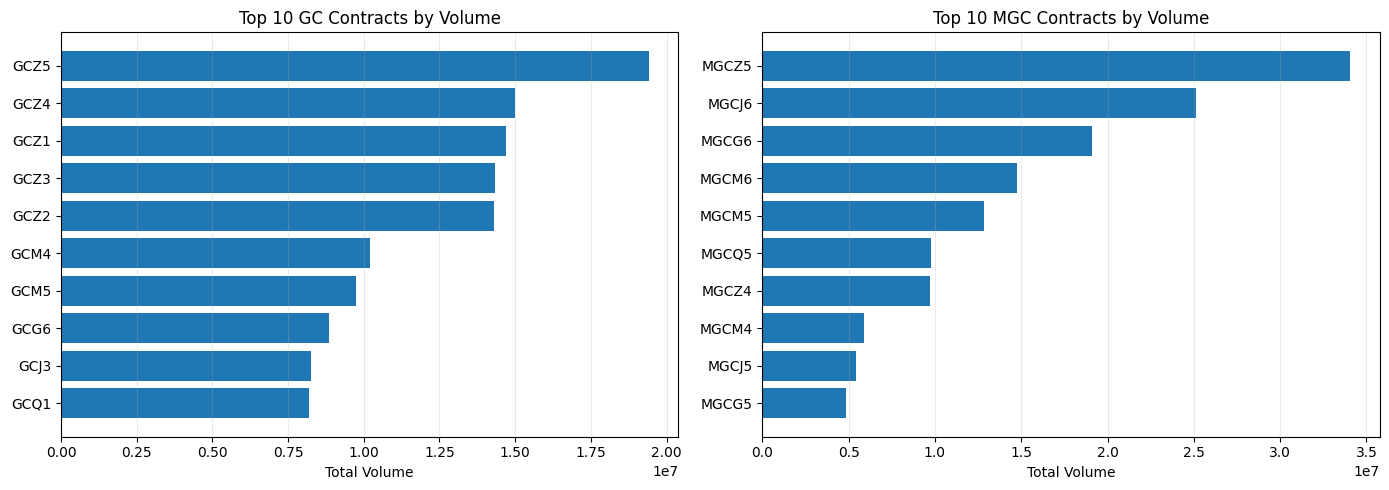

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, product in zip(axes, ["GC", "MGC"]):
    plot_data = (
        liquidity_by_contract[liquidity_by_contract["product"].eq(product)]
        .sort_values("total_volume", ascending=False)
        .head(10)
        .sort_values("total_volume")
    )
    ax.barh(plot_data["symbol"], plot_data["total_volume"])
    ax.set_title(f"Top 10 {product} Contracts by Volume")
    ax.set_xlabel("Total Volume")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()


### 3.3.2 Daily Volume Evolution


In [47]:
daily_contract_volume = (
    outrights
    .reset_index()
    .assign(trade_date=lambda x: pd.to_datetime(x["ts_event"].dt.date))
    .groupby(["trade_date", "product", "symbol"], observed=True)
    .agg(
        daily_volume=("volume", "sum"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

daily_product_volume = (
    daily_contract_volume
    .groupby(["trade_date", "product"], observed=True)
    .agg(
        daily_volume=("daily_volume", "sum"),
        active_contracts=("symbol", "nunique"),
        bars=("bars", "sum"),
    )
    .reset_index()
    .sort_values(["product", "trade_date"])
)

daily_product_volume["volume_20d_avg"] = (
    daily_product_volume
    .groupby("product", observed=True)["daily_volume"]
    .transform(lambda x: x.rolling(20, min_periods=1).mean())
)

daily_volume_summary = daily_product_volume.groupby("product", observed=True).agg(
    trading_days=("trade_date", "nunique"),
    median_daily_volume=("daily_volume", "median"),
    mean_daily_volume=("daily_volume", "mean"),
    max_daily_volume=("daily_volume", "max"),
    median_active_contracts=("active_contracts", "median"),
    max_active_contracts=("active_contracts", "max"),
)

daily_volume_summary


,trading_days,median_daily_volume,mean_daily_volume,max_daily_volume,median_active_contracts,max_active_contracts
product,,,,,,
GC,1555,156668.0,148465.377492,537850,9.0,22
MGC,1555,58888.0,120028.101608,1536127,7.0,12


In [48]:
daily_product_volume.tail(20)


,trade_date,product,daily_volume,active_contracts,bars,volume_20d_avg
3071,2026-04-30,MGC,325481,8,2568,300066.15
3073,2026-05-01,MGC,275357,8,2352,291781.85
3075,2026-05-03,MGC,17921,4,192,273586.70
3077,2026-05-04,MGC,325505,9,2704,275126.25
3079,2026-05-05,MGC,281983,8,2502,287215.10
3081,2026-05-06,MGC,337540,8,2809,287419.00
3083,2026-05-07,MGC,381228,9,2837,289587.60
3085,2026-05-08,MGC,265146,8,2352,286593.70
3087,2026-05-10,MGC,18936,6,244,272285.40
3089,2026-05-11,MGC,317892,8,2828,270395.45


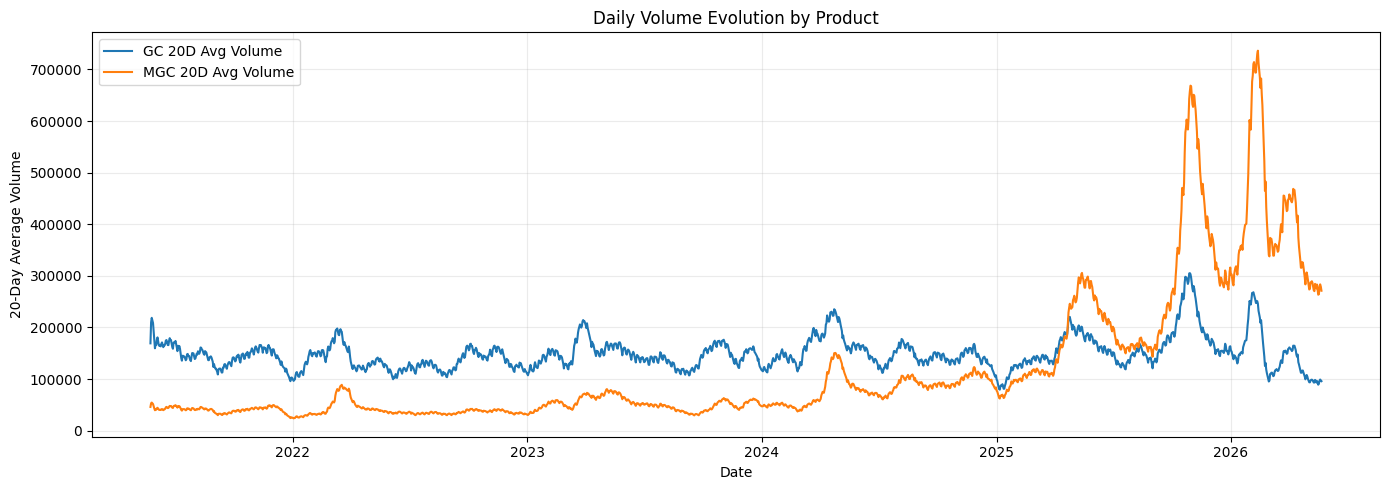

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in daily_product_volume.groupby("product", observed=True):
    ax.plot(group["trade_date"], group["volume_20d_avg"], label=f"{product} 20D Avg Volume")

ax.set_title("Daily Volume Evolution by Product")
ax.set_xlabel("Date")
ax.set_ylabel("20-Day Average Volume")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


### 3.3.3 Contract Dominance Over Time


In [50]:
idx = daily_contract_volume.groupby(["trade_date", "product"], observed=True)["daily_volume"].idxmax()

dominant_contract_by_day = (
    daily_contract_volume
    .loc[idx]
    .rename(columns={"symbol": "dominant_contract", "daily_volume": "dominant_contract_volume"})
    .sort_values(["product", "trade_date"])
    .reset_index(drop=True)
)

dominant_contract_by_day = dominant_contract_by_day.merge(
    daily_product_volume[["trade_date", "product", "daily_volume", "active_contracts"]].rename(columns={"daily_volume": "product_daily_volume"}),
    on=["trade_date", "product"],
    how="left",
)

dominant_contract_by_day["dominant_volume_share"] = (
    dominant_contract_by_day["dominant_contract_volume"]
    / dominant_contract_by_day["product_daily_volume"]
)

dominance_summary = dominant_contract_by_day.groupby("product", observed=True).agg(
    days=("trade_date", "nunique"),
    median_dominant_share=("dominant_volume_share", "median"),
    mean_dominant_share=("dominant_volume_share", "mean"),
    min_dominant_share=("dominant_volume_share", "min"),
    max_dominant_share=("dominant_volume_share", "max"),
)

dominance_summary


,days,median_dominant_share,mean_dominant_share,min_dominant_share,max_dominant_share
product,,,,,
GC,1555,0.970085,0.947532,0.478205,0.995617
MGC,1555,0.975164,0.953860,0.498151,0.998254


In [51]:
dominant_contract_summary = (
    dominant_contract_by_day
    .groupby(["product", "dominant_contract"], observed=True)
    .agg(
        days_dominant=("trade_date", "nunique"),
        first_dominant_day=("trade_date", "min"),
        last_dominant_day=("trade_date", "max"),
        total_volume_while_dominant=("dominant_contract_volume", "sum"),
        avg_dominant_share=("dominant_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "days_dominant", "total_volume_while_dominant"], ascending=[True, False, False])
)

dominant_contract_summary.groupby("product", observed=True).head(15)


,product,dominant_contract,days_dominant,first_dominant_day,last_dominant_day,total_volume_while_dominant,avg_dominant_share
22,GC,GCZ2,106,2022-07-28,2022-11-28,13938639,0.952950
23,GC,GCZ3,105,2023-07-28,2023-11-27,13847674,0.958700
24,GC,GCZ4,104,2024-07-29,2024-11-26,14623392,0.953257
21,GC,GCZ1,103,2021-07-29,2021-11-25,14293833,0.965540
25,GC,GCZ5,102,2025-07-29,2025-11-24,19117887,0.951425
4,GC,GCG6,55,2025-11-25,2026-01-27,8504688,0.941378
16,GC,GCQ1,55,2021-05-26,2021-07-28,8092084,0.947364
13,GC,GCM4,54,2024-03-26,2024-05-28,9721512,0.949562
3,GC,GCG5,54,2024-11-27,2025-01-28,5661245,0.947371
20,GC,GCQ5,53,2025-05-28,2025-07-28,7184812,0.948498


In [52]:
dominant_contract_by_day.tail(30)


,trade_date,product,dominant_contract,dominant_contract_volume,bars,product_daily_volume,active_contracts,dominant_volume_share
3080,2026-04-19,MGC,MGCM6,40045,120,40741,8,0.982916
3081,2026-04-20,MGC,MGCM6,303735,1380,306682,8,0.990391
3082,2026-04-21,MGC,MGCM6,423537,1380,427950,10,0.989688
3083,2026-04-22,MGC,MGCM6,257382,1380,259934,10,0.990182
3084,2026-04-23,MGC,MGCM6,412505,1380,416532,11,0.990332
3085,2026-04-24,MGC,MGCM6,305165,1260,307835,8,0.991327
3086,2026-04-26,MGC,MGCM6,19390,120,19653,7,0.986618
3087,2026-04-27,MGC,MGCM6,272563,1380,275146,11,0.990612
3088,2026-04-28,MGC,MGCM6,397075,1380,401627,11,0.988666
3089,2026-04-29,MGC,MGCM6,400590,1380,404820,9,0.989551


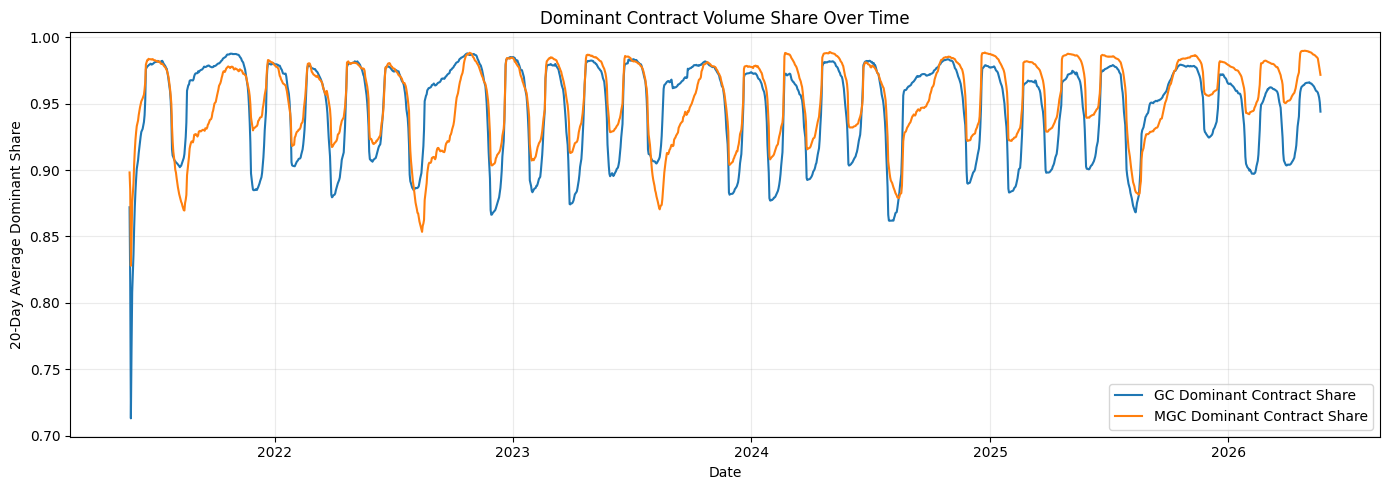

In [53]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in dominant_contract_by_day.groupby("product", observed=True):
    rolling_share = group.set_index("trade_date")["dominant_volume_share"].rolling(20, min_periods=1).mean()
    ax.plot(rolling_share.index, rolling_share.values, label=f"{product} Dominant Contract Share")

ax.set_title("Dominant Contract Volume Share Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("20-Day Average Dominant Share")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


### 3.3.4 Liquidity Migration


In [54]:
# Smooth daily contract volume before detecting liquidity migration.
# This avoids treating one-day volume noise as a true rollover/migration event.
rolling_contract_volume = daily_contract_volume.sort_values(["product", "symbol", "trade_date"]).copy()
rolling_contract_volume["rolling_5d_volume"] = (
    rolling_contract_volume
    .groupby(["product", "symbol"], observed=True)["daily_volume"]
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

idx = rolling_contract_volume.groupby(["trade_date", "product"], observed=True)["rolling_5d_volume"].idxmax()

rolling_dominant_contract = (
    rolling_contract_volume
    .loc[idx]
    .rename(columns={"symbol": "rolling_dominant_contract"})
    .sort_values(["product", "trade_date"])
    .reset_index(drop=True)
)

rolling_dominant_contract = rolling_dominant_contract.merge(
    daily_product_volume[["trade_date", "product", "daily_volume"]].rename(columns={"daily_volume": "product_daily_volume"}),
    on=["trade_date", "product"],
    how="left",
)
rolling_dominant_contract["daily_volume_share"] = (
    rolling_dominant_contract["daily_volume"] / rolling_dominant_contract["product_daily_volume"]
)

rolling_dominant_contract["previous_dominant_contract"] = (
    rolling_dominant_contract
    .groupby("product", observed=True)["rolling_dominant_contract"]
    .shift(1)
)

liquidity_migration_events = rolling_dominant_contract[
    rolling_dominant_contract["previous_dominant_contract"].notna()
    & rolling_dominant_contract["rolling_dominant_contract"].ne(rolling_dominant_contract["previous_dominant_contract"])
].copy()

liquidity_migration_events[[
    "trade_date",
    "product",
    "previous_dominant_contract",
    "rolling_dominant_contract",
    "daily_volume",
    "rolling_5d_volume",
    "daily_volume_share",
]].tail(30)


,trade_date,product,previous_dominant_contract,rolling_dominant_contract,daily_volume,rolling_5d_volume,daily_volume_share
1248,2025-05-29,GC,GCM5,GCQ5,190324,412295.0,0.943174
1301,2025-07-30,GC,GCQ5,GCZ5,187394,354343.0,0.894277
1404,2025-11-27,GC,GCZ5,GCG6,71513,433240.0,0.969168
1458,2026-01-29,GC,GCG6,GCJ6,503462,1056206.0,0.936064
1509,2026-03-30,GC,GCJ6,GCM6,137009,397149.0,0.937724
1560,2021-05-30,MGC,MGCM1,MGCQ1,640,113150.0,0.962406
1614,2021-08-01,MGC,MGCQ1,MGCZ1,1137,85750.0,0.821532
1718,2021-11-30,MGC,MGCZ1,MGCG2,72984,135677.0,0.983705
1771,2022-02-01,MGC,MGCG2,MGCJ2,27598,110336.0,0.982835
1821,2022-03-31,MGC,MGCJ2,MGCM2,51277,142580.0,0.988968


In [55]:
migration_summary = liquidity_migration_events.groupby("product", observed=True).agg(
    migration_events=("trade_date", "count"),
    first_migration=("trade_date", "min"),
    last_migration=("trade_date", "max"),
)

migration_summary


,migration_events,first_migration,last_migration
product,,,
GC,25,2021-05-28,2026-03-30
MGC,25,2021-05-30,2026-03-31


In [56]:
rolling_dominant_timeline = (
    rolling_dominant_contract
    .assign(month=lambda x: x["trade_date"].dt.strftime("%Y-%m"))
    .groupby(["month", "product", "rolling_dominant_contract"], observed=True)
    .agg(
        days_as_rolling_dominant=("trade_date", "nunique"),
        total_daily_volume=("daily_volume", "sum"),
        avg_daily_volume_share=("daily_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "month", "days_as_rolling_dominant"], ascending=[True, True, False])
)

rolling_dominant_timeline.tail(40)


,month,product,rolling_dominant_contract,days_as_rolling_dominant,total_daily_volume,avg_daily_volume_share
90,2024-01,MGC,MGCJ4,1,71621,0.987944
92,2024-02,MGC,MGCJ4,25,1023316,0.987298
95,2024-03,MGC,MGCJ4,23,1178005,0.884182
96,2024-03,MGC,MGCM4,2,117949,0.983852
98,2024-04,MGC,MGCM4,26,3571697,0.987944
101,2024-05,MGC,MGCM4,26,2000345,0.911218
102,2024-05,MGC,MGCQ4,1,83417,0.976060
104,2024-06,MGC,MGCQ4,25,1658986,0.979943
107,2024-07,MGC,MGCQ4,26,1870407,0.885661
108,2024-07,MGC,MGCZ4,1,82752,0.891340


### 3.3.5 Preliminary Front-Month Investigation


In [57]:
# First-pass front-month candidate: the contract with the highest rolling 5-day volume per product/date.
# This is a liquidity-based candidate, not yet a finalized rollover rule.
front_month_candidates = rolling_dominant_contract.rename(
    columns={"rolling_dominant_contract": "front_month_candidate"}
).copy()

front_month_summary = (
    front_month_candidates
    .groupby(["product", "front_month_candidate"], observed=True)
    .agg(
        first_candidate_day=("trade_date", "min"),
        last_candidate_day=("trade_date", "max"),
        days_as_candidate=("trade_date", "nunique"),
        total_volume_as_candidate=("daily_volume", "sum"),
        avg_daily_volume_as_candidate=("daily_volume", "mean"),
        avg_volume_share_as_candidate=("daily_volume_share", "mean"),
    )
    .reset_index()
    .sort_values(["product", "first_candidate_day", "front_month_candidate"])
)

front_month_summary.tail(30)


,product,front_month_candidate,first_candidate_day,last_candidate_day,days_as_candidate,total_volume_as_candidate,avg_daily_volume_as_candidate,avg_volume_share_as_candidate
25,GC,GCZ5,2025-07-30,2025-11-26,103,19081594,185258.194175,0.939270
4,GC,GCG6,2025-11-27,2026-01-28,54,8236610,152529.814815,0.930423
9,GC,GCJ6,2026-01-29,2026-03-29,51,7042036,138079.137255,0.903376
15,GC,GCM6,2026-03-30,2026-05-22,46,4616492,100358.521739,0.954174
36,MGC,MGCM1,2021-05-24,2021-05-28,5,138775,27755.000000,0.513202
42,MGC,MGCQ1,2021-05-30,2021-07-30,54,2157268,39949.407407,0.929199
47,MGC,MGCZ1,2021-08-01,2021-11-29,104,3944108,37924.115385,0.928489
26,MGC,MGCG2,2021-11-30,2022-01-31,53,1487866,28072.943396,0.903796
31,MGC,MGCJ2,2022-02-01,2022-03-30,50,2840271,56805.420000,0.933413
37,MGC,MGCM2,2022-03-31,2022-05-29,50,1842892,36857.840000,0.925406


In [58]:
front_month_recent_timeline = front_month_candidates[[
    "trade_date",
    "product",
    "front_month_candidate",
    "daily_volume",
    "rolling_5d_volume",
    "daily_volume_share",
]].tail(60)

front_month_recent_timeline


,trade_date,product,front_month_candidate,daily_volume,rolling_5d_volume,daily_volume_share
3050,2026-03-13,MGC,MGCJ6,321393,1704096.0,0.973898
3051,2026-03-15,MGC,MGCJ6,45897,1348392.0,0.963980
3052,2026-03-16,MGC,MGCJ6,405199,1409504.0,0.976021
3053,2026-03-17,MGC,MGCJ6,299151,1408154.0,0.975164
3054,2026-03-18,MGC,MGCJ6,508116,1579756.0,0.963259
3055,2026-03-19,MGC,MGCJ6,766879,2025242.0,0.957732
3056,2026-03-20,MGC,MGCJ6,609534,2588879.0,0.956040
3057,2026-03-22,MGC,MGCJ6,59749,2243429.0,0.935698
3058,2026-03-23,MGC,MGCJ6,1068207,3012485.0,0.929468
3059,2026-03-24,MGC,MGCJ6,665403,3169772.0,0.936345


In [59]:
front_month_quality = front_month_candidates.groupby("product", observed=True).agg(
    days=("trade_date", "nunique"),
    median_candidate_volume_share=("daily_volume_share", "median"),
    mean_candidate_volume_share=("daily_volume_share", "mean"),
    min_candidate_volume_share=("daily_volume_share", "min"),
    max_candidate_volume_share=("daily_volume_share", "max"),
)

front_month_quality


,days,median_candidate_volume_share,mean_candidate_volume_share,min_candidate_volume_share,max_candidate_volume_share
product,,,,,
GC,1555,0.970085,0.933524,0.002874,0.995617
MGC,1555,0.974926,0.931605,0.002777,0.998254


**3.3 Liquidity Analysis Notes**

* `liquidity_by_contract` ranks contracts by total observed volume.
* `daily_product_volume` tracks GC/MGC volume through time.
* `dominant_contract_by_day` identifies the single highest-volume contract each day.
* `rolling_dominant_contract` smooths dominance using 5-day rolling volume to reduce one-day noise.
* `front_month_candidates` is the first liquidity-based approximation of a front-month series.

**Next:** 3.4 Session Analysis.


## Liquidity Analysis Report

**3.3 Liquidity Analysis**

**3.3.1 Volume by Contract**

**Results**

For **GC**, the highest-volume contracts are primarily December delivery contracts:

* GCZ5
* GCZ4
* GCZ1
* GCZ3
* GCZ2

The largest GC contract is:

```text
Contract:      GCZ5
Total Volume:  19,414,779
Bars:          158,853
Volume Share:  8.41%
```

For **MGC**, the highest-volume contracts are:

* MGCZ5
* MGCJ6
* MGCG6
* MGCM6
* MGCM5

The largest MGC contract is:

```text
Contract:      MGCZ5
Total Volume:  34,056,711
Bars:          144,900
Volume Share:  18.25%
```

The concentration of liquidity differs between the two products:

```text
Top 5 GC Contracts:  33.7% of total GC outright volume
Top 5 MGC Contracts: 56.7% of total MGC outright volume
```

**Conclusion**

Liquidity is highly concentrated in a relatively small number of contracts. MGC exhibits an even greater concentration of trading activity than GC, indicating that only a handful of contracts account for the majority of market participation. Consequently, not all listed contracts should be treated equally during strategy development.

---

**3.3.2 Daily Volume Evolution**

**Results**

```text
GC
Median Daily Volume: 156,668
Mean Daily Volume:   148,465
Maximum Volume:      537,850

MGC
Median Daily Volume:  58,888
Mean Daily Volume:   120,028
Maximum Volume:    1,536,127
```

Typical daily contract activity:

```text
GC Median Active Contracts Per Day:  9
MGC Median Active Contracts Per Day: 7
```

GC demonstrates higher typical daily liquidity, while MGC experiences substantially larger volume spikes during periods of elevated market activity.

Although several contracts are active on any given day, trading volume remains highly concentrated in only one or two contracts.

**Conclusion**

Contract activity alone is not a reliable indicator of liquidity. Most trading occurs within a small subset of active contracts, reinforcing the need for liquidity-based contract selection rather than simply considering every active contract.

---

**3.3.3 Contract Dominance Over Time**

**Results**

```text
GC
Median Dominant Share: 97.0%
Mean Dominant Share:   94.8%

MGC
Median Dominant Share: 97.5%
Mean Dominant Share:   95.4%
```

Representative dominant contracts include:

* GCZ1
* GCZ2
* GCZ3
* GCZ4
* GCZ5

and

* MGCZ1
* MGCZ2
* MGCZ3
* MGCZ4
* MGCZ5

Each dominant contract remains the primary source of liquidity for approximately one hundred days before liquidity migrates to the next active delivery month.

**Conclusion**

One contract typically accounts for approximately **95–97%** of total daily trading volume. This strongly supports constructing a continuous futures series based on the dominant contract rather than combining observations from all listed contracts.

---

**3.3.4 Liquidity Migration**

**Results**

```text
GC Migration Events:  25
MGC Migration Events: 25
```

Using a rolling five-day volume measure, liquidity transitions follow the expected delivery sequence.

Recent GC migrations include:

```text
GCM5 → GCQ5
GCQ5 → GCZ5
GCZ5 → GCG6
GCG6 → GCJ6
GCJ6 → GCM6
```

Recent MGC migrations include:

```text
MGCQ5 → MGCZ5
MGCZ5 → MGCG6
MGCG6 → MGCJ6
MGCJ6 → MGCM6
```

The rolling five-day approach reduces temporary one-day fluctuations and produces a more stable identification of contract rollovers.

**Conclusion**

Liquidity migration follows the expected futures delivery cycle rather than occurring randomly. A rolling-volume approach provides a strong foundation for identifying rollover points during continuous futures construction.

---

**3.3.5 Preliminary Front-Month Investigation**

The preliminary front-month candidate is defined as:

> The contract with the highest rolling five-day trading volume for each product and trading day.

Recent MGC front-month candidates transitioned from:

```text
MGCJ6 → MGCM6
```

with the rollover occurring approximately on:

```text
2026-03-31
```

**Front-Month Quality Summary**

```text
GC
Median Candidate Share: 97.0%
Mean Candidate Share:   93.4%
Minimum Share:           0.29%

MGC
Median Candidate Share: 97.5%
Mean Candidate Share:   93.2%
Minimum Share:           0.28%
```

The high median values indicate that the rolling-volume method successfully identifies the dominant trading contract in most cases.

The very low minimum values likely occur during rollover periods, exchange holidays, shortened trading sessions, or situations where the five-day rolling winner differs from the highest-volume contract on the current day.

**Conclusion**

The rolling five-day volume method provides an effective starting point for front-month identification. However, additional rollover safeguards should be incorporated before adopting it as the final methodology for constructing a continuous futures series.

---

**3.3.6 Summary**

**Key Findings**

```text
Top 5 GC Contracts:
33.7% of total outright volume

Top 5 MGC Contracts:
56.7% of total outright volume

Median Dominant Contract Share:
GC:  97.0%
MGC: 97.5%

Observed Liquidity Migrations:
GC:  25
MGC: 25

Primary Delivery Cycle:
G → J → M → Q → Z
```

**Overall Assessment**

The liquidity characteristics of both GC and MGC are well defined. Although numerous contracts trade simultaneously, market activity is overwhelmingly concentrated in a single dominant contract on most trading days. Liquidity then migrates systematically through the standard major delivery cycle rather than switching randomly between contracts.

These findings provide strong evidence that the next stage of the research should focus on constructing a robust front-month series based on observed liquidity migration rather than predetermined calendar roll dates.

The recommended workflow for subsequent strategy development is:

1. Restrict analysis to outright contracts.
2. Focus primarily on the major delivery months (G, J, M, Q, Z).
3. Construct a liquidity-based front-month series.
4. Incorporate rollover safeguards to improve continuity.
5. Proceed with session analysis, volatility analysis, return modelling, and signal research using the resulting continuous dataset.


## 3.4 Session Analysis


This section studies how liquidity and volatility behave across the trading day.

To avoid multi-contract distortion, the analysis uses the preliminary liquidity-based front-month candidate from 3.3: one active contract per product per date.


### 3.4.1 Volume by Hour


In [60]:
# Build an active/front-contract dataset from the 3.3 liquidity-based candidate.
# This keeps one selected contract per product/date for session analysis.
# Engineering note: keep this dataframe narrow; the full outright table is several million rows.
import time

_t0 = time.perf_counter()

active_contract_keys = (
    front_month_candidates[["trade_date", "product", "front_month_candidate"]]
    .rename(columns={"front_month_candidate": "symbol"})
)

active_front_source = outrights[[
    "product",
    "symbol",
    "open",
    "high",
    "low",
    "close",
    "volume",
]].reset_index()

# Match 3.3's UTC trade_date definition without using slower object-date conversion.
active_front_source["trade_date"] = active_front_source["ts_event"].dt.tz_convert(None).dt.normalize().astype("datetime64[s]")

active_front = active_front_source.merge(
    active_contract_keys,
    on=["trade_date", "product", "symbol"],
    how="inner",
).sort_values(["product", "symbol", "ts_event"], ignore_index=True)

active_front["front_month_candidate"] = active_front["symbol"]
active_front["ts_ny"] = active_front["ts_event"].dt.tz_convert("America/New_York")
active_front["hour_ny"] = active_front["ts_ny"].dt.hour
active_front["minute_ny"] = active_front["ts_ny"].dt.minute
active_front["minute_of_day_ny"] = active_front["hour_ny"] * 60 + active_front["minute_ny"]
active_front["trade_date_ny"] = active_front["ts_ny"].dt.tz_localize(None).dt.normalize().astype("datetime64[s]")

active_front_build_seconds = time.perf_counter() - _t0

active_front_shape = pd.Series({
    "rows": len(active_front),
    "products": active_front["product"].nunique(),
    "symbols": active_front["symbol"].nunique(),
    "start_utc": active_front["ts_event"].min(),
    "end_utc": active_front["ts_event"].max(),
    "build_seconds": round(active_front_build_seconds, 2),
})

active_front_shape


rows                               3493667
products                                 2
symbols                                 52
start_utc        2021-05-24 00:00:00+00:00
end_utc          2026-05-22 20:59:00+00:00
build_seconds                         2.34
dtype: object

In [61]:
hourly_volume = (
    active_front
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        median_volume_per_bar=("volume", "median"),
    )
    .reset_index()
)

hourly_volume["product_volume_share"] = (
    hourly_volume["total_volume"]
    / hourly_volume.groupby("product")["total_volume"].transform("sum")
)

hourly_volume


,product,hour_ny,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,product_volume_share
0,GC,0,76835,3766269,49.017622,28.0,0.017489
1,GC,1,77106,5285640,68.550307,43.0,0.024544
2,GC,2,77213,7589365,98.291285,69.0,0.035242
3,GC,3,77266,8937986,115.678125,82.0,0.041504
4,GC,4,77227,8036175,104.059137,71.0,0.037317
5,GC,5,77188,7204894,93.342152,62.0,0.033457
6,GC,6,77190,6931997,89.804340,59.0,0.032189
7,GC,7,77185,8513651,110.301885,76.0,0.039534
8,GC,8,77323,22635009,292.733197,190.0,0.105108
9,GC,9,77369,26766568,345.959855,261.0,0.124293


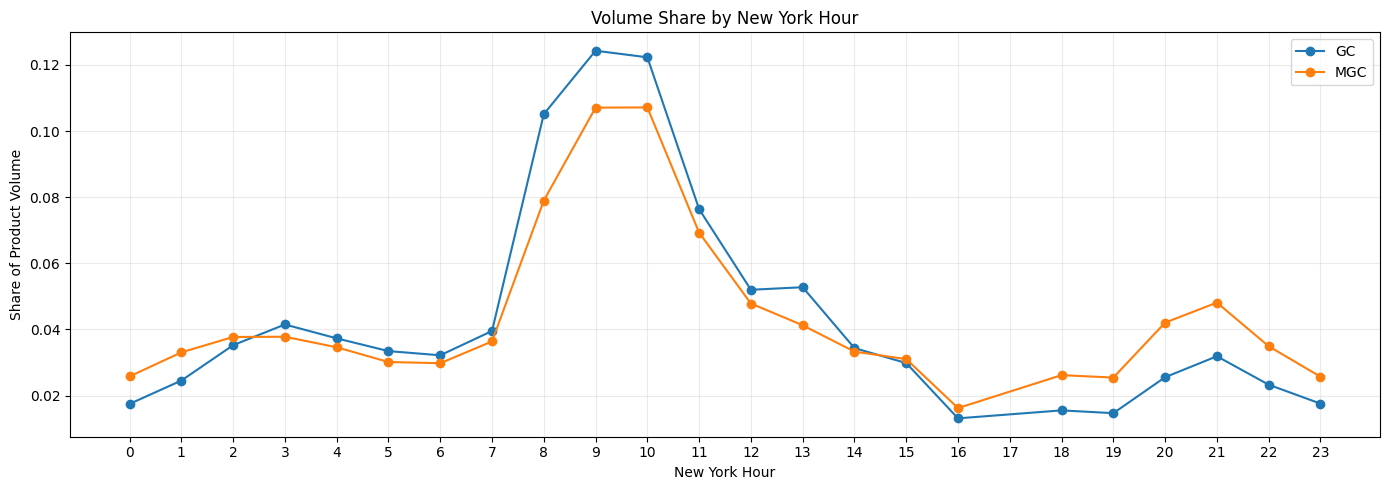

In [62]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in hourly_volume.groupby("product", observed=True):
    ax.plot(group["hour_ny"], group["product_volume_share"], marker="o", label=product)

ax.set_title("Volume Share by New York Hour")
ax.set_xlabel("New York Hour")
ax.set_ylabel("Share of Product Volume")
ax.set_xticks(range(24))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


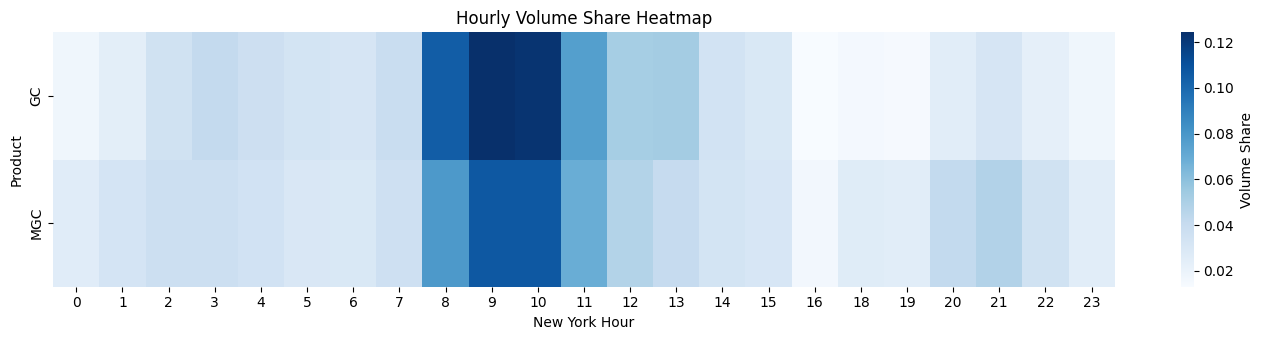

In [63]:
hourly_volume_pivot = hourly_volume.pivot(index="product", columns="hour_ny", values="product_volume_share")

plt.figure(figsize=(14, 3.5))
sns.heatmap(hourly_volume_pivot, cmap="Blues", annot=False, cbar_kws={"label": "Volume Share"})
plt.title("Hourly Volume Share Heatmap")
plt.xlabel("New York Hour")
plt.ylabel("Product")
plt.tight_layout()


### 3.4.2 Volatility by Hour


In [64]:
import time

_t0 = time.perf_counter()

# Compute log(close) once, then use groupby.diff. This avoids running np.log inside
# every group and preserves the same per-contract return logic.
active_front["log_close"] = np.log(active_front["close"])
active_front["log_return"] = (
    active_front
    .groupby(["product", "symbol"], observed=True, sort=False)["log_close"]
    .diff()
)
active_front["abs_log_return"] = active_front["log_return"].abs()
active_front["squared_log_return"] = active_front["log_return"] ** 2
active_front.drop(columns="log_close", inplace=True)

hourly_volatility = (
    active_front
    .dropna(subset=["log_return"])
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        observations=("log_return", "size"),
        mean_abs_log_return=("abs_log_return", "mean"),
        median_abs_log_return=("abs_log_return", "median"),
        return_std=("log_return", "std"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
)

hourly_volatility["realized_vol"] = np.sqrt(hourly_volatility["realized_variance"])
hourly_volatility_build_seconds = time.perf_counter() - _t0

print(f"Built hourly_volatility in {hourly_volatility_build_seconds:.2f} seconds")
hourly_volatility


Built hourly_volatility in 0.86 seconds


,product,hour_ny,observations,mean_abs_log_return,median_abs_log_return,return_std,realized_variance,realized_vol
0,GC,0,76835,0.000124,0.000085,0.000204,0.003201,0.056577
1,GC,1,77106,0.000155,0.000108,0.000250,0.004832,0.069515
2,GC,2,77213,0.000181,0.000127,0.000269,0.005585,0.074731
3,GC,3,77266,0.000194,0.000147,0.000287,0.006368,0.079800
4,GC,4,77227,0.000180,0.000120,0.000276,0.005891,0.076752
5,GC,5,77188,0.000162,0.000112,0.000244,0.004584,0.067708
6,GC,6,77190,0.000161,0.000111,0.000249,0.004768,0.069051
7,GC,7,77185,0.000178,0.000119,0.000284,0.006214,0.078832
8,GC,8,77323,0.000295,0.000206,0.000461,0.016441,0.128222
9,GC,9,77369,0.000328,0.000240,0.000467,0.016875,0.129903


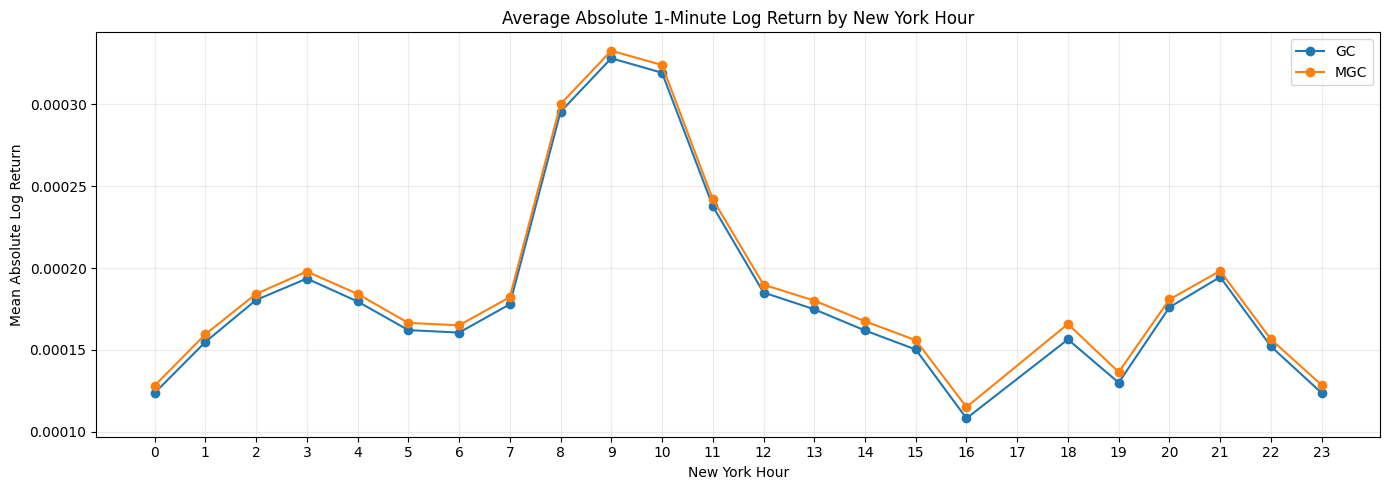

In [65]:
fig, ax = plt.subplots(figsize=(14, 5))

for product, group in hourly_volatility.groupby("product", observed=True):
    ax.plot(group["hour_ny"], group["mean_abs_log_return"], marker="o", label=product)

ax.set_title("Average Absolute 1-Minute Log Return by New York Hour")
ax.set_xlabel("New York Hour")
ax.set_ylabel("Mean Absolute Log Return")
ax.set_xticks(range(24))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


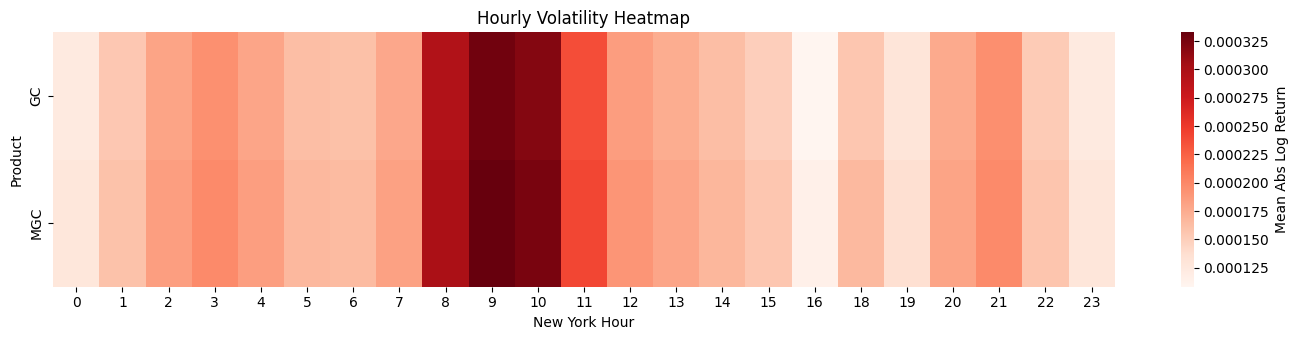

In [66]:
vol_heatmap = hourly_volatility.pivot(index="product", columns="hour_ny", values="mean_abs_log_return")

plt.figure(figsize=(14, 3.5))
sns.heatmap(vol_heatmap, cmap="Reds", annot=False, cbar_kws={"label": "Mean Abs Log Return"})
plt.title("Hourly Volatility Heatmap")
plt.xlabel("New York Hour")
plt.ylabel("Product")
plt.tight_layout()


### 3.4.3 London Session Behavior


In [67]:
import time

_t0 = time.perf_counter()

minute_of_day = active_front["minute_of_day_ny"]
session_order = ["Overnight/Asia", "London", "New York", "Post-NY", "Maintenance/Other"]

active_front["session"] = np.select(
    [
        minute_of_day.between(3 * 60, 8 * 60 + 19),
        minute_of_day.between(8 * 60 + 20, 13 * 60 + 29),
        minute_of_day.between(13 * 60 + 30, 17 * 60 - 1),
        (minute_of_day >= 18 * 60) | (minute_of_day < 3 * 60),
    ],
    ["London", "New York", "Post-NY", "Overnight/Asia"],
    default="Maintenance/Other",
)
active_front["session"] = pd.Categorical(active_front["session"], categories=session_order, ordered=True)

session_label_seconds = time.perf_counter() - _t0

london = active_front.loc[active_front["session"].eq("London")]

london_summary = london.dropna(subset=["log_return"]).groupby("product", observed=True).agg(
    bars=("symbol", "size"),
    total_volume=("volume", "sum"),
    avg_volume_per_bar=("volume", "mean"),
    median_volume_per_bar=("volume", "median"),
    mean_abs_log_return=("abs_log_return", "mean"),
    realized_variance=("squared_log_return", "sum"),
)
london_summary["realized_vol"] = np.sqrt(london_summary["realized_variance"])

print(f"Labeled sessions in {session_label_seconds:.2f} seconds")
london_summary


Labeled sessions in 0.87 seconds


,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,mean_abs_log_return,realized_variance,realized_vol
product,,,,,,,
GC,411823,44408273,107.833397,73.0,0.000179,0.031076,0.176284
MGC,406255,33018991,81.276516,36.0,0.000183,0.031771,0.178244


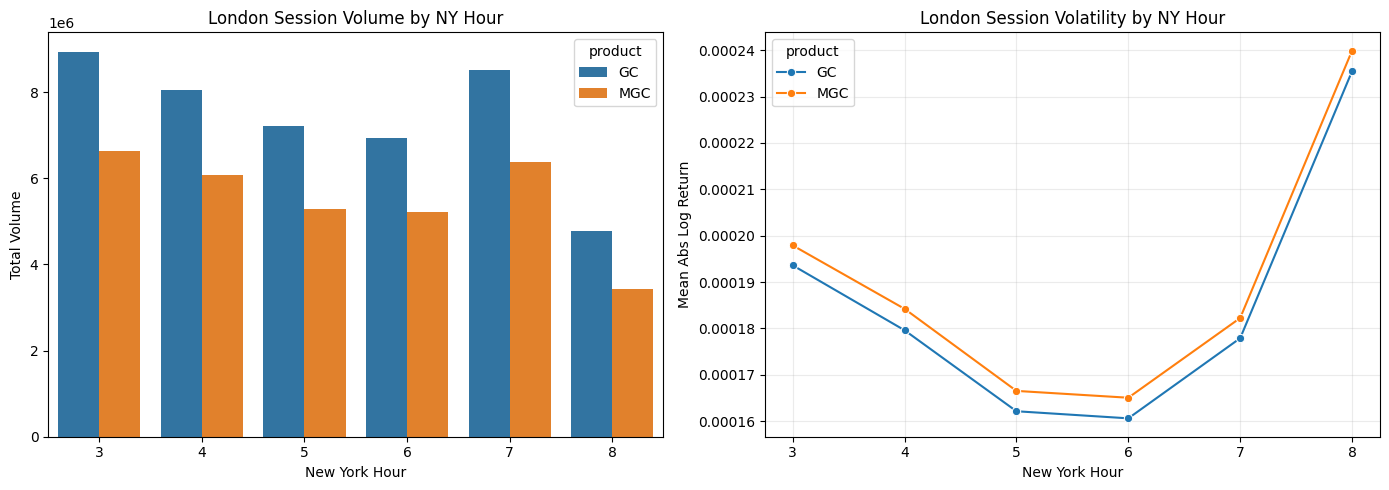

In [68]:
london_hourly = (
    london
    .dropna(subset=["log_return"])
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        total_volume=("volume", "sum"),
        mean_abs_log_return=("abs_log_return", "mean"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=london_hourly, x="hour_ny", y="total_volume", hue="product", ax=axes[0])
axes[0].set_title("London Session Volume by NY Hour")
axes[0].set_xlabel("New York Hour")
axes[0].set_ylabel("Total Volume")

sns.lineplot(data=london_hourly, x="hour_ny", y="mean_abs_log_return", hue="product", marker="o", ax=axes[1])
axes[1].set_title("London Session Volatility by NY Hour")
axes[1].set_xlabel("New York Hour")
axes[1].set_ylabel("Mean Abs Log Return")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.4.4 New York Session Behavior


In [69]:
new_york = active_front.loc[active_front["session"].eq("New York")]

new_york_summary = new_york.dropna(subset=["log_return"]).groupby("product", observed=True).agg(
    bars=("symbol", "size"),
    total_volume=("volume", "sum"),
    avg_volume_per_bar=("volume", "mean"),
    median_volume_per_bar=("volume", "median"),
    mean_abs_log_return=("abs_log_return", "mean"),
    realized_variance=("squared_log_return", "sum"),
)
new_york_summary["realized_vol"] = np.sqrt(new_york_summary["realized_variance"])

new_york_summary


,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,mean_abs_log_return,realized_variance,realized_vol
product,,,,,,,
GC,399189,105645308,264.649848,177.0,0.000267,0.067304,0.259430
MGC,396281,72554448,183.088384,86.0,0.000272,0.068771,0.262242


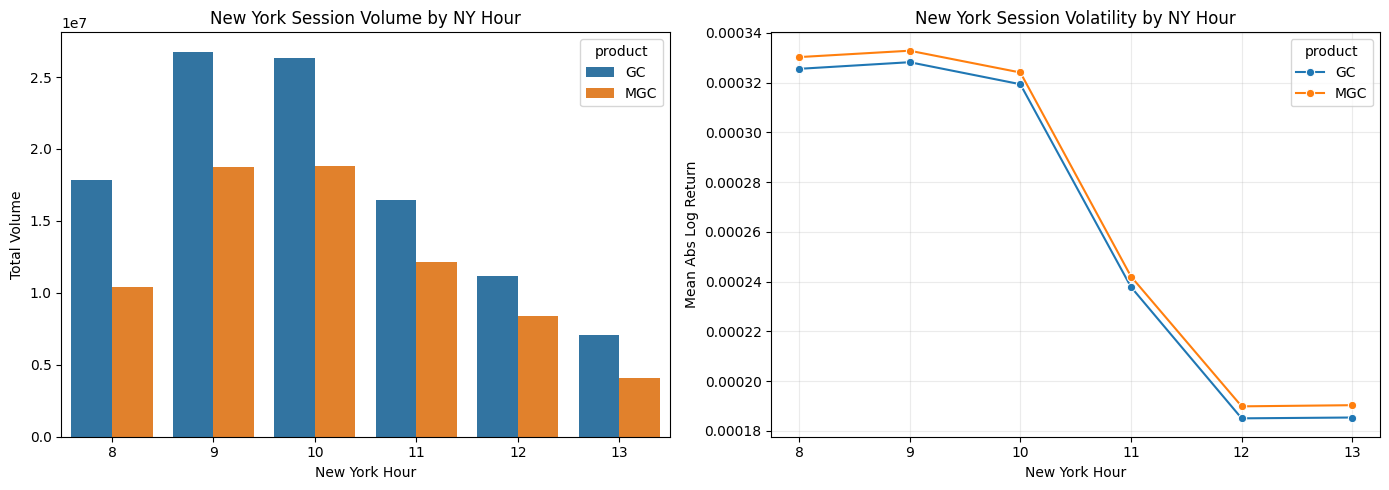

In [70]:
new_york_hourly = (
    new_york
    .dropna(subset=["log_return"])
    .groupby(["product", "hour_ny"], observed=True)
    .agg(
        total_volume=("volume", "sum"),
        mean_abs_log_return=("abs_log_return", "mean"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=new_york_hourly, x="hour_ny", y="total_volume", hue="product", ax=axes[0])
axes[0].set_title("New York Session Volume by NY Hour")
axes[0].set_xlabel("New York Hour")
axes[0].set_ylabel("Total Volume")

sns.lineplot(data=new_york_hourly, x="hour_ny", y="mean_abs_log_return", hue="product", marker="o", ax=axes[1])
axes[1].set_title("New York Session Volatility by NY Hour")
axes[1].set_xlabel("New York Hour")
axes[1].set_ylabel("Mean Abs Log Return")
axes[1].grid(alpha=0.25)

plt.tight_layout()


### 3.4.5 Session Comparison


In [71]:
session_summary = (
    active_front
    .dropna(subset=["log_return"])
    .groupby(["product", "session"], observed=True)
    .agg(
        bars=("symbol", "size"),
        total_volume=("volume", "sum"),
        avg_volume_per_bar=("volume", "mean"),
        median_volume_per_bar=("volume", "median"),
        mean_abs_log_return=("abs_log_return", "mean"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
)

session_summary["realized_vol"] = np.sqrt(session_summary["realized_variance"])
session_summary["volume_share"] = (
    session_summary["total_volume"]
    / session_summary.groupby("product", observed=True)["total_volume"].transform("sum")
)
session_summary["realized_variance_share"] = (
    session_summary["realized_variance"]
    / session_summary.groupby("product", observed=True)["realized_variance"].transform("sum")
)

session_summary


,product,session,bars,total_volume,avg_volume_per_bar,median_volume_per_bar,mean_abs_log_return,realized_variance,realized_vol,volume_share,realized_variance_share
0,GC,Overnight/Asia,690083,44320082,64.224277,37.0,0.000155,0.052297,0.228685,0.205808,0.313043
1,GC,London,411823,44408273,107.833397,73.0,0.000179,0.031076,0.176284,0.206217,0.186018
2,GC,New York,399189,105645308,264.649848,177.0,0.000267,0.067304,0.259430,0.490582,0.402874
3,GC,Post-NY,262034,20973196,80.039980,47.0,0.000144,0.016383,0.127995,0.097393,0.098065
4,MGC,Overnight/Asia,672535,52430329,77.959257,23.0,0.000160,0.052736,0.229643,0.299066,0.309346
5,MGC,London,406255,33018991,81.276516,36.0,0.000183,0.031771,0.178244,0.188342,0.186367
6,MGC,New York,396281,72554448,183.088384,86.0,0.000272,0.068771,0.262242,0.413855,0.403406
7,MGC,Post-NY,255415,17309988,67.772010,24.0,0.000150,0.017198,0.131140,0.098737,0.100881


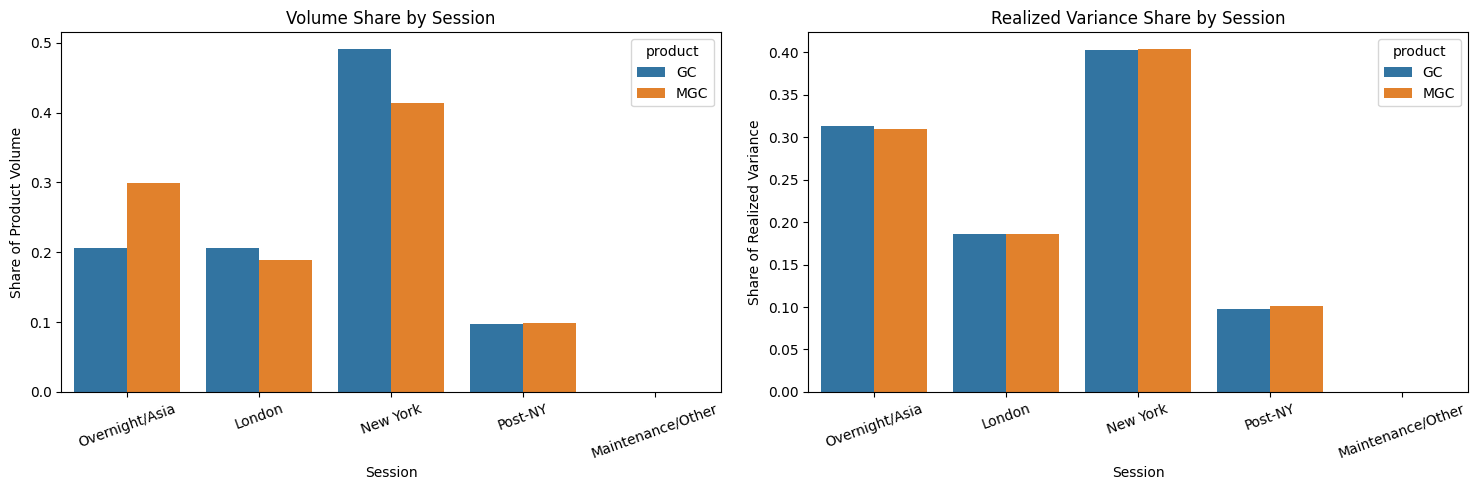

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=session_summary, x="session", y="volume_share", hue="product", ax=axes[0])
axes[0].set_title("Volume Share by Session")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Share of Product Volume")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=session_summary, x="session", y="realized_variance_share", hue="product", ax=axes[1])
axes[1].set_title("Realized Variance Share by Session")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Share of Realized Variance")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


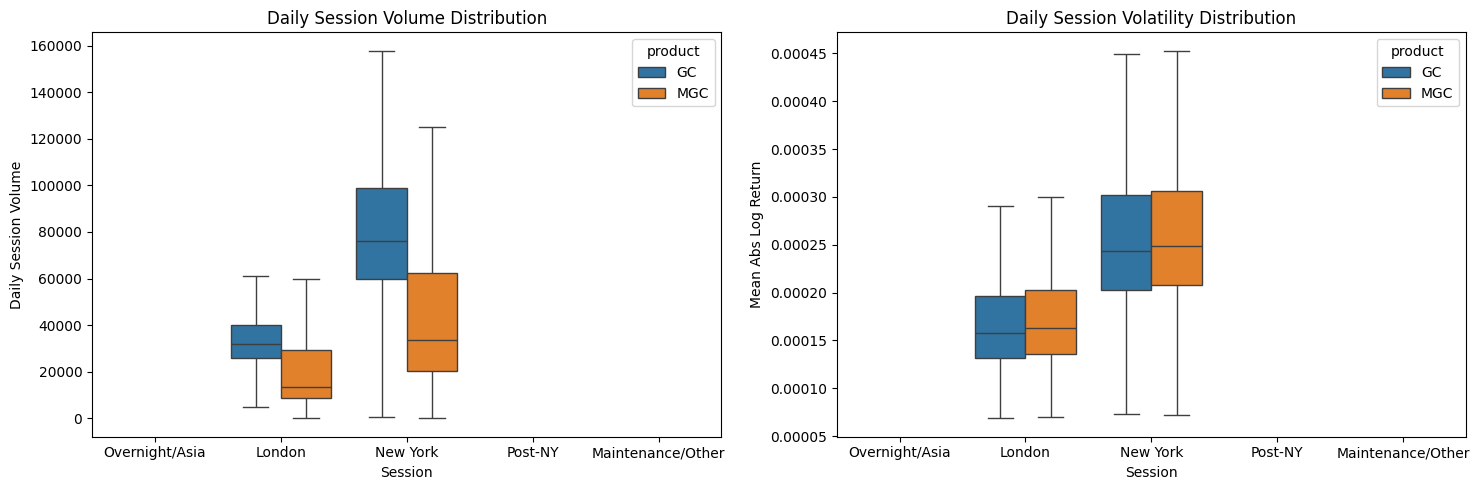

In [73]:
daily_session = (
    active_front
    .dropna(subset=["log_return"])
    .groupby(["trade_date_ny", "product", "session"], observed=True)
    .agg(
        session_volume=("volume", "sum"),
        realized_variance=("squared_log_return", "sum"),
        mean_abs_log_return=("abs_log_return", "mean"),
        bars=("symbol", "size"),
    )
    .reset_index()
)

daily_session_focus = daily_session[daily_session["session"].isin(["London", "New York"])]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=daily_session_focus, x="session", y="session_volume", hue="product", ax=axes[0], showfliers=False)
axes[0].set_title("Daily Session Volume Distribution")
axes[0].set_xlabel("Session")
axes[0].set_ylabel("Daily Session Volume")

sns.boxplot(data=daily_session_focus, x="session", y="mean_abs_log_return", hue="product", ax=axes[1], showfliers=False)
axes[1].set_title("Daily Session Volatility Distribution")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Mean Abs Log Return")

plt.tight_layout()


**3.4 Session Analysis Notes**

* Session analysis uses the liquidity-selected active/front contract, not the full multi-contract dataset.
* Timestamps are converted from UTC to `America/New_York` for session labels.
* London is defined as 03:00-08:19 NY time.
* New York is defined as 08:20-13:29 NY time.
* Post-NY is defined as 13:30-16:59 NY time.
* Overnight/Asia is defined as 18:00-02:59 NY time.

**Next:** 3.5 Volatility Analysis.


## 3.5 Volatility Analysis


This section studies volatility using the liquidity-selected active/front contract series created in 3.4.

The goal is to understand return dispersion, intraday volatility structure, daily realized volatility, volatility regimes, and volatility clustering before moving into signal design.


### 3.5.1 Return Distribution


In [74]:
import time

_t0 = time.perf_counter()
print("Starting 3.5.1 return distribution build...")

# 3.5 is designed to run after 3.4. Rebuild return columns only if needed.
required_return_cols = {"log_return", "abs_log_return", "squared_log_return"}
if not required_return_cols.issubset(active_front.columns):
    print("Return columns missing; rebuilding from active_front close prices...")
    active_front["log_close"] = np.log(active_front["close"])
    active_front["log_return"] = (
        active_front
        .groupby(["product", "symbol"], observed=True, sort=False)["log_close"]
        .diff()
    )
    active_front["abs_log_return"] = active_front["log_return"].abs()
    active_front["squared_log_return"] = active_front["log_return"] ** 2
    active_front.drop(columns="log_close", inplace=True)
else:
    print("Reusing existing return columns from 3.4.")

return_cols = [
    "ts_event",
    "trade_date_ny",
    "product",
    "symbol",
    "session",
    "hour_ny",
    "minute_ny",
    "volume",
    "log_return",
    "abs_log_return",
    "squared_log_return",
]

returns = active_front.loc[active_front["log_return"].notna(), return_cols].copy()
returns["return_bps"] = returns["log_return"].to_numpy() * 10_000
returns["abs_return_bps"] = returns["abs_log_return"].to_numpy() * 10_000

print(f"Prepared returns dataframe: {len(returns):,} rows in {time.perf_counter() - _t0:.2f}s")

summary_rows = []
for product, product_returns in returns.groupby("product", observed=True, sort=False):
    values = product_returns["return_bps"].to_numpy(dtype="float64", copy=False)
    abs_values = np.abs(values)
    q01, q05, q95, q99 = np.quantile(values, [0.01, 0.05, 0.95, 0.99])
    mean = values.mean()
    std = values.std(ddof=1)
    centered = values - mean
    m2 = np.mean(centered ** 2)
    m3 = np.mean(centered ** 3)
    m4 = np.mean(centered ** 4)
    skewness = m3 / (m2 ** 1.5)
    excess_kurtosis = m4 / (m2 ** 2) - 3

    summary_rows.append({
        "product": product,
        "observations": len(values),
        "mean_bps": mean,
        "median_bps": np.median(values),
        "std_bps": std,
        "skewness": skewness,
        "min_bps": values.min(),
        "q01_bps": q01,
        "q05_bps": q05,
        "q95_bps": q95,
        "q99_bps": q99,
        "max_bps": values.max(),
        "excess_kurtosis": excess_kurtosis,
        "mean_abs_bps": abs_values.mean(),
    })

return_distribution_summary = pd.DataFrame(summary_rows).set_index("product")

return_distribution_seconds = time.perf_counter() - _t0
print(f"Built return distribution summary in {return_distribution_seconds:.2f} seconds")
return_distribution_summary


Starting 3.5.1 return distribution build...
Reusing existing return columns from 3.4.
Prepared returns dataframe: 3,493,615 rows in 0.36s
Built return distribution summary in 0.75 seconds


,observations,mean_bps,median_bps,std_bps,skewness,min_bps,q01_bps,q05_bps,q95_bps,q99_bps,max_bps,excess_kurtosis,mean_abs_bps
product,,,,,,,,,,,,,
GC,1763129,0.003799,0.0,3.078175,-1.058388,-243.706725,-8.360565,-4.069116,4.108886,8.282637,179.325275,120.742241,1.841467
MGC,1730486,0.003905,0.0,3.138676,-1.071726,-254.099241,-8.476337,-4.161743,4.187944,8.369966,174.017704,126.304638,1.895972


Built precomputed return histogram in 0.20 seconds


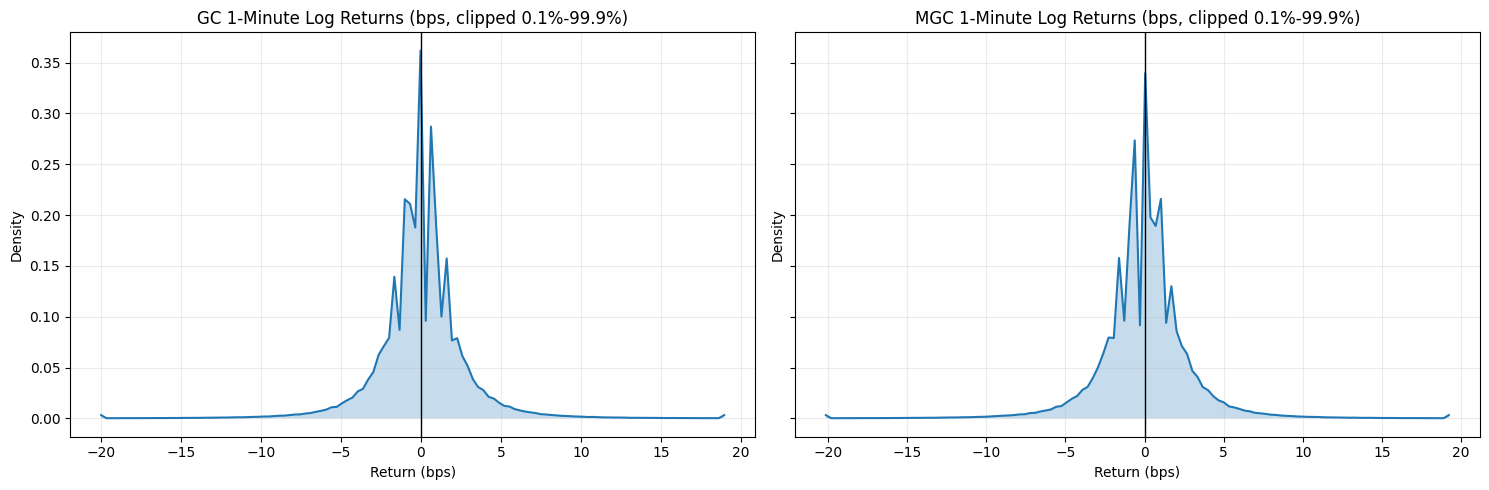

In [75]:
# Precompute histogram bins instead of passing millions of raw rows into seaborn.
# This makes the visualization much faster and more predictable.
_t0 = time.perf_counter()

histogram_rows = []
for product, product_returns in returns.groupby("product", observed=True, sort=False):
    values = product_returns["return_bps"].to_numpy(dtype="float64", copy=False)
    lower, upper = np.quantile(values, [0.001, 0.999])
    clipped = np.clip(values, lower, upper)
    counts, bin_edges = np.histogram(clipped, bins=120, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    histogram_rows.append(pd.DataFrame({
        "product": product,
        "return_bps_clipped": bin_centers,
        "density": counts,
    }))

return_histogram = pd.concat(histogram_rows, ignore_index=True)
print(f"Built precomputed return histogram in {time.perf_counter() - _t0:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, product in zip(axes, ["GC", "MGC"]):
    plot_data = return_histogram[return_histogram["product"].eq(product)]
    ax.plot(plot_data["return_bps_clipped"], plot_data["density"], linewidth=1.5)
    ax.fill_between(plot_data["return_bps_clipped"], plot_data["density"], alpha=0.25)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{product} 1-Minute Log Returns (bps, clipped 0.1%-99.9%)")
    ax.set_xlabel("Return (bps)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)

plt.tight_layout()


In [76]:
tail_thresholds_bps = [5, 10, 20, 50]

_t0 = time.perf_counter()
tail_flags = returns[["product", "abs_return_bps"]].copy()
for threshold in tail_thresholds_bps:
    tail_flags[f"pct_abs_return_gt_{threshold}_bps"] = tail_flags["abs_return_bps"].to_numpy() > threshold

tail_risk_summary = (
    tail_flags
    .groupby("product", observed=True)[[f"pct_abs_return_gt_{threshold}_bps" for threshold in tail_thresholds_bps]]
    .mean()
)

print(f"Built tail risk summary in {time.perf_counter() - _t0:.2f} seconds")
tail_risk_summary


Built tail risk summary in 0.17 seconds


,pct_abs_return_gt_5_bps,pct_abs_return_gt_10_bps,pct_abs_return_gt_20_bps,pct_abs_return_gt_50_bps
product,,,,
GC,0.066410,0.012399,0.001910,0.000121
MGC,0.069201,0.012772,0.001964,0.000127


### 3.5.2 Intraday Volatility


In [77]:
import time

_t0 = time.perf_counter()

returns["half_hour_ny"] = (returns["hour_ny"] * 60 + returns["minute_ny"]) // 30 * 30
returns["half_hour_label"] = (returns["half_hour_ny"] // 60).astype(str).str.zfill(2) + ":" + (returns["half_hour_ny"] % 60).astype(str).str.zfill(2)

intraday_volatility = (
    returns
    .groupby(["product", "half_hour_ny", "half_hour_label"], observed=True)
    .agg(
        observations=("log_return", "size"),
        total_volume=("volume", "sum"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        median_abs_return_bps=("abs_return_bps", "median"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
    .sort_values(["product", "half_hour_ny"])
)
intraday_volatility["realized_vol"] = np.sqrt(intraday_volatility["realized_variance"])
intraday_volatility["rv_share"] = intraday_volatility["realized_variance"] / intraday_volatility.groupby("product", observed=True)["realized_variance"].transform("sum")
intraday_volatility["volume_share"] = intraday_volatility["total_volume"] / intraday_volatility.groupby("product", observed=True)["total_volume"].transform("sum")

intraday_volatility_seconds = time.perf_counter() - _t0
print(f"Built intraday_volatility in {intraday_volatility_seconds:.2f} seconds")
intraday_volatility.head(20)


Built intraday_volatility in 3.18 seconds


,product,half_hour_ny,half_hour_label,observations,total_volume,mean_abs_return_bps,median_abs_return_bps,realized_variance,realized_vol,rv_share,volume_share
0,GC,0,00:00,38370,1704016,1.160132,0.761325,0.001287,0.035882,0.007707,0.007913
1,GC,30,00:30,38465,2062253,1.313859,0.921192,0.001913,0.043744,0.011454,0.009576
2,GC,60,01:00,38523,2262568,1.404681,1.018330,0.002052,0.045298,0.012283,0.010507
3,GC,90,01:30,38583,3023072,1.692302,1.123343,0.002780,0.052730,0.016644,0.014038
4,GC,120,02:00,38606,3927876,1.871970,1.426359,0.002937,0.054190,0.017578,0.018240
5,GC,150,02:30,38607,3661489,1.738588,1.192926,0.002648,0.051461,0.015852,0.017003
6,GC,180,03:00,38642,4783239,2.013688,1.508656,0.003377,0.058111,0.020214,0.022212
7,GC,210,03:30,38624,4154747,1.858213,1.383253,0.002991,0.054691,0.017904,0.019293
8,GC,240,04:00,38635,4329529,1.899541,1.339172,0.003330,0.057706,0.019933,0.020105
9,GC,270,04:30,38592,3706646,1.692154,1.139147,0.002561,0.050605,0.015329,0.017212


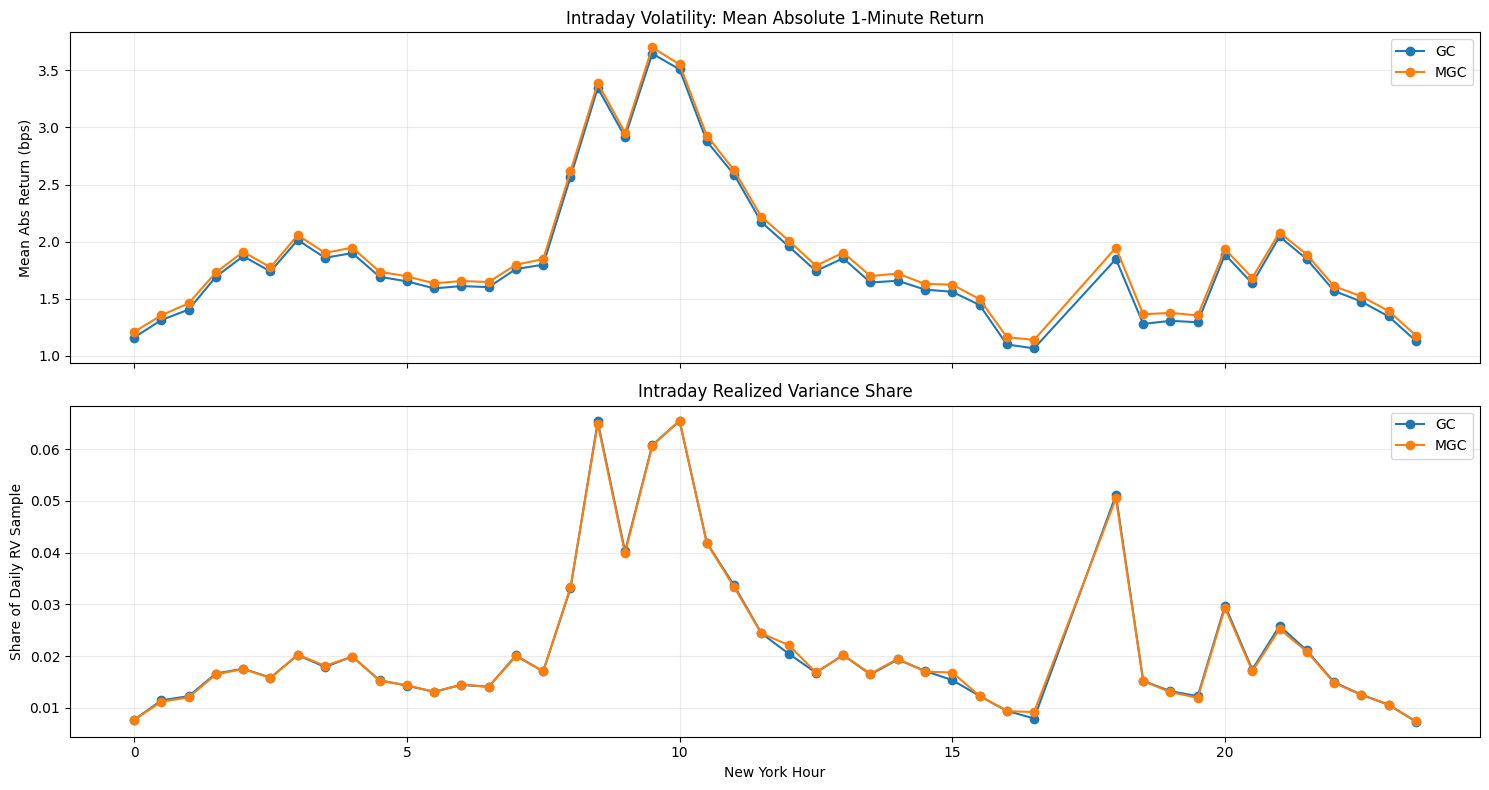

In [78]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for product, group in intraday_volatility.groupby("product", observed=True):
    axes[0].plot(group["half_hour_ny"] / 60, group["mean_abs_return_bps"], marker="o", label=product)
    axes[1].plot(group["half_hour_ny"] / 60, group["rv_share"], marker="o", label=product)

axes[0].set_title("Intraday Volatility: Mean Absolute 1-Minute Return")
axes[0].set_ylabel("Mean Abs Return (bps)")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title("Intraday Realized Variance Share")
axes[1].set_xlabel("New York Hour")
axes[1].set_ylabel("Share of Daily RV Sample")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()


In [79]:
session_volatility = (
    returns
    .groupby(["product", "session"], observed=True)
    .agg(
        observations=("log_return", "size"),
        total_volume=("volume", "sum"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        median_abs_return_bps=("abs_return_bps", "median"),
        realized_variance=("squared_log_return", "sum"),
    )
    .reset_index()
)
session_volatility["realized_vol"] = np.sqrt(session_volatility["realized_variance"])
session_volatility["rv_share"] = session_volatility["realized_variance"] / session_volatility.groupby("product", observed=True)["realized_variance"].transform("sum")
session_volatility["volume_share"] = session_volatility["total_volume"] / session_volatility.groupby("product", observed=True)["total_volume"].transform("sum")

session_volatility


,product,session,observations,total_volume,mean_abs_return_bps,median_abs_return_bps,realized_variance,realized_vol,rv_share,volume_share
0,GC,Overnight/Asia,690083,44320082,1.547525,1.031513,0.052297,0.228685,0.313043,0.205808
1,GC,London,411823,44408273,1.785603,1.188707,0.031076,0.176284,0.186018,0.206217
2,GC,New York,399189,105645308,2.672147,1.797160,0.067304,0.259430,0.402874,0.490582
3,GC,Post-NY,262034,20973196,1.437900,0.984155,0.016383,0.127995,0.098065,0.097393
4,MGC,Overnight/Asia,672535,52430329,1.600583,1.070435,0.052736,0.229643,0.309346,0.299066
5,MGC,London,406255,33018991,1.830174,1.252296,0.031771,0.178244,0.186367,0.188342
6,MGC,New York,396281,72554448,2.720288,1.871573,0.068771,0.262242,0.403406,0.413855
7,MGC,Post-NY,255415,17309988,1.499477,1.018641,0.017198,0.131140,0.100881,0.098737


### 3.5.3 Daily Volatility


In [80]:
import time

_t0 = time.perf_counter()

daily_volatility = (
    returns
    .groupby(["trade_date_ny", "product"], observed=True)
    .agg(
        observations=("log_return", "size"),
        daily_volume=("volume", "sum"),
        realized_variance=("squared_log_return", "sum"),
        mean_abs_return_bps=("abs_return_bps", "mean"),
        max_abs_return_bps=("abs_return_bps", "max"),
    )
    .reset_index()
    .sort_values(["product", "trade_date_ny"])
)

daily_volatility["realized_vol"] = np.sqrt(daily_volatility["realized_variance"])
daily_volatility["realized_vol_bps"] = daily_volatility["realized_vol"] * 10_000

daily_volatility["rv_20d_mean"] = (
    daily_volatility
    .groupby("product", observed=True)["realized_vol_bps"]
    .transform(lambda x: x.rolling(20, min_periods=5).mean())
)
daily_volatility["rv_60d_mean"] = (
    daily_volatility
    .groupby("product", observed=True)["realized_vol_bps"]
    .transform(lambda x: x.rolling(60, min_periods=20).mean())
)

daily_volatility_summary = daily_volatility.groupby("product", observed=True).agg(
    days=("trade_date_ny", "nunique"),
    median_realized_vol_bps=("realized_vol_bps", "median"),
    mean_realized_vol_bps=("realized_vol_bps", "mean"),
    p90_realized_vol_bps=("realized_vol_bps", lambda x: x.quantile(0.90)),
    max_realized_vol_bps=("realized_vol_bps", "max"),
    median_daily_volume=("daily_volume", "median"),
)

daily_volatility_seconds = time.perf_counter() - _t0
print(f"Built daily_volatility in {daily_volatility_seconds:.2f} seconds")
daily_volatility_summary


Built daily_volatility in 0.29 seconds


,days,median_realized_vol_bps,mean_realized_vol_bps,p90_realized_vol_bps,max_realized_vol_bps,median_daily_volume
product,,,,,,
GC,1556,80.519219,89.686801,136.751054,601.675109,141969.0
MGC,1556,82.238637,91.001120,137.872341,601.102092,57490.5


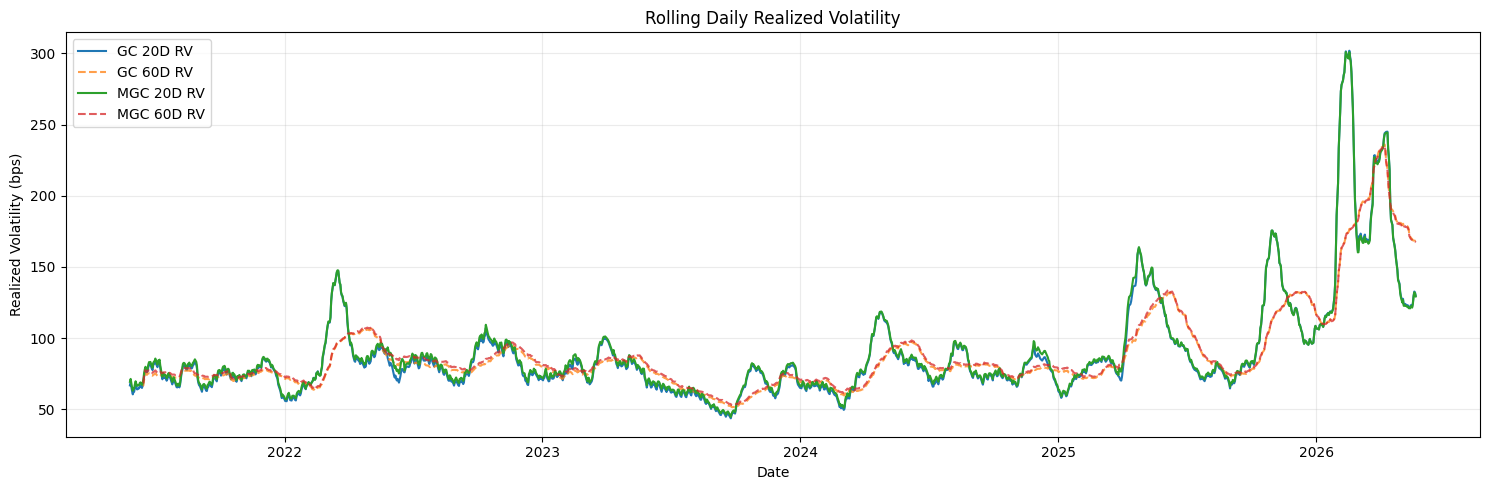

In [81]:
fig, ax = plt.subplots(figsize=(15, 5))

for product, group in daily_volatility.groupby("product", observed=True):
    ax.plot(group["trade_date_ny"], group["rv_20d_mean"], label=f"{product} 20D RV")
    ax.plot(group["trade_date_ny"], group["rv_60d_mean"], linestyle="--", alpha=0.75, label=f"{product} 60D RV")

ax.set_title("Rolling Daily Realized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Realized Volatility (bps)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


In [82]:
top_daily_volatility = (
    daily_volatility
    .sort_values(["product", "realized_vol_bps"], ascending=[True, False])
    .groupby("product", observed=True)
    .head(10)
)

top_daily_volatility[["trade_date_ny", "product", "realized_vol_bps", "daily_volume", "max_abs_return_bps", "observations"]]


,trade_date_ny,product,realized_vol_bps,daily_volume,max_abs_return_bps,observations
2924,2026-02-02,GC,601.675109,301767,95.552759,1380
2918,2026-01-29,GC,598.424967,505268,243.706725,1380
3008,2026-03-23,GC,589.928011,295938,128.238102,1380
2920,2026-01-30,GC,578.163967,377934,114.130878,1020
2922,2026-02-01,GC,562.254833,101869,215.031044,360
2930,2026-02-05,GC,426.199127,215190,82.216274,1380
2928,2026-02-04,GC,384.331086,248112,64.159943,1380
3002,2026-03-19,GC,375.870577,264840,72.057250,1380
2974,2026-03-03,GC,364.573769,249947,70.466848,1380
3010,2026-03-24,GC,351.273538,186012,117.283478,1380


### 3.5.4 Volatility Regimes


In [83]:
# Regime labels are based on product-specific daily realized volatility thresholds.
# This avoids groupby.apply shape/index side effects and keeps the operation explicit.
regime_order = ["Low", "Normal", "High", "Extreme"]

vol_regime_thresholds = (
    daily_volatility
    .groupby("product", observed=True)["realized_vol_bps"]
    .quantile([0.25, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: "q25", 0.75: "q75", 0.90: "q90"})
)

daily_volatility = daily_volatility.merge(
    vol_regime_thresholds,
    on="product",
    how="left",
)

daily_volatility["vol_regime"] = np.select(
    [
        daily_volatility["realized_vol_bps"] <= daily_volatility["q25"],
        daily_volatility["realized_vol_bps"] <= daily_volatility["q75"],
        daily_volatility["realized_vol_bps"] <= daily_volatility["q90"],
    ],
    ["Low", "Normal", "High"],
    default="Extreme",
)

daily_volatility["vol_regime"] = pd.Categorical(daily_volatility["vol_regime"], categories=regime_order, ordered=True)
daily_volatility.drop(columns=["q25", "q75", "q90"], inplace=True)

volatility_regime_summary = (
    daily_volatility
    .groupby(["product", "vol_regime"], observed=True)
    .agg(
        days=("trade_date_ny", "nunique"),
        median_realized_vol_bps=("realized_vol_bps", "median"),
        mean_realized_vol_bps=("realized_vol_bps", "mean"),
        median_daily_volume=("daily_volume", "median"),
        mean_abs_return_bps=("mean_abs_return_bps", "mean"),
        max_abs_return_bps=("max_abs_return_bps", "max"),
    )
)

volatility_regime_summary


days  median_realized_vol_bps  mean_realized_vol_bps  \
product vol_regime                                                         
GC      Low          389                49.024490              46.280526   
        Normal       778                80.519219              81.792854   
        High         233               114.343000             115.889356   
        Extreme      156               166.192053             198.156908   
MGC     Low          389                49.867059              47.271725   
        Normal       778                82.238637              83.381450   
        High         233               115.653881             117.243517   
        Extreme      156               169.350124             198.849576   

                    median_daily_volume  mean_abs_return_bps  \
product vol_regime                                             
GC      Low                     39006.0             1.237892   
        Normal                 148495.5             1.620594   
        High                   189297.0             2.267891   
        Extreme                201550.5             4.011413   
MGC     Low                     24017.0             1.321676   
        Normal                  58597.0             1.683876   
        High                   128142.0             2.314903   
        Extreme                326061.0             4.030181   

                    max_abs_return_bps  
product vol_regime                      
GC      Low                  48.423750  
        Normal               65.967962  
        High                 88.937387  
        Extreme             243.706725  
MGC     Low                  48.937638  
        Normal               68.904866  
        High                 90.025136  
        Extreme             254.099241

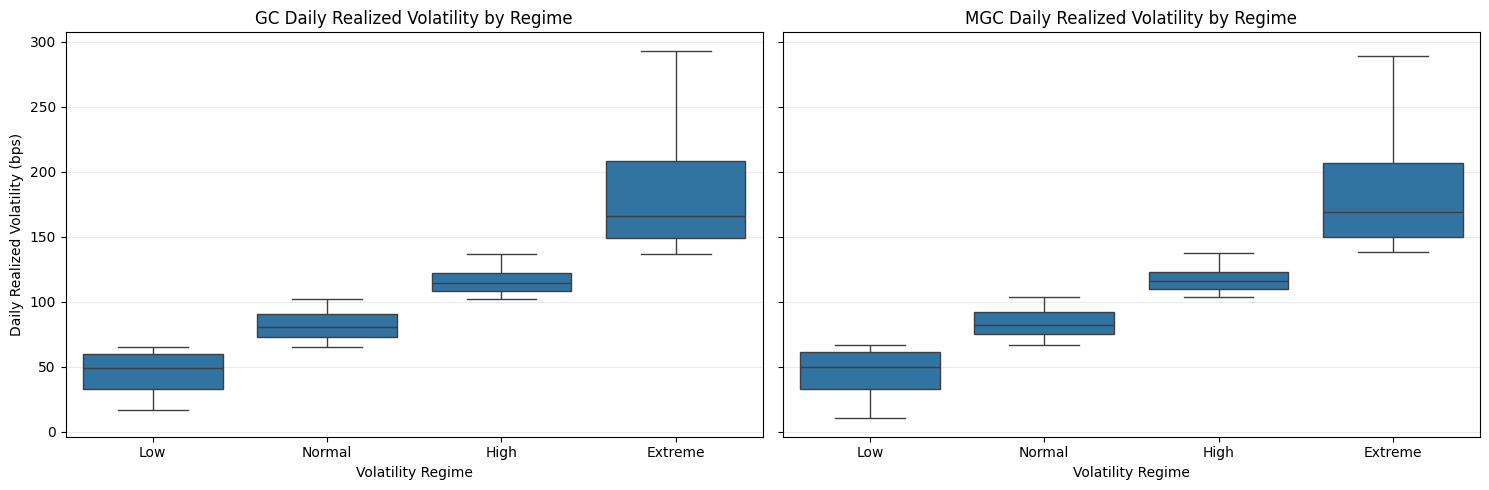

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, product in zip(axes, ["GC", "MGC"]):
    product_daily = daily_volatility[daily_volatility["product"].eq(product)]
    sns.boxplot(data=product_daily, x="vol_regime", y="realized_vol_bps", order=regime_order, ax=ax, showfliers=False)
    ax.set_title(f"{product} Daily Realized Volatility by Regime")
    ax.set_xlabel("Volatility Regime")
    ax.set_ylabel("Daily Realized Volatility (bps)")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()


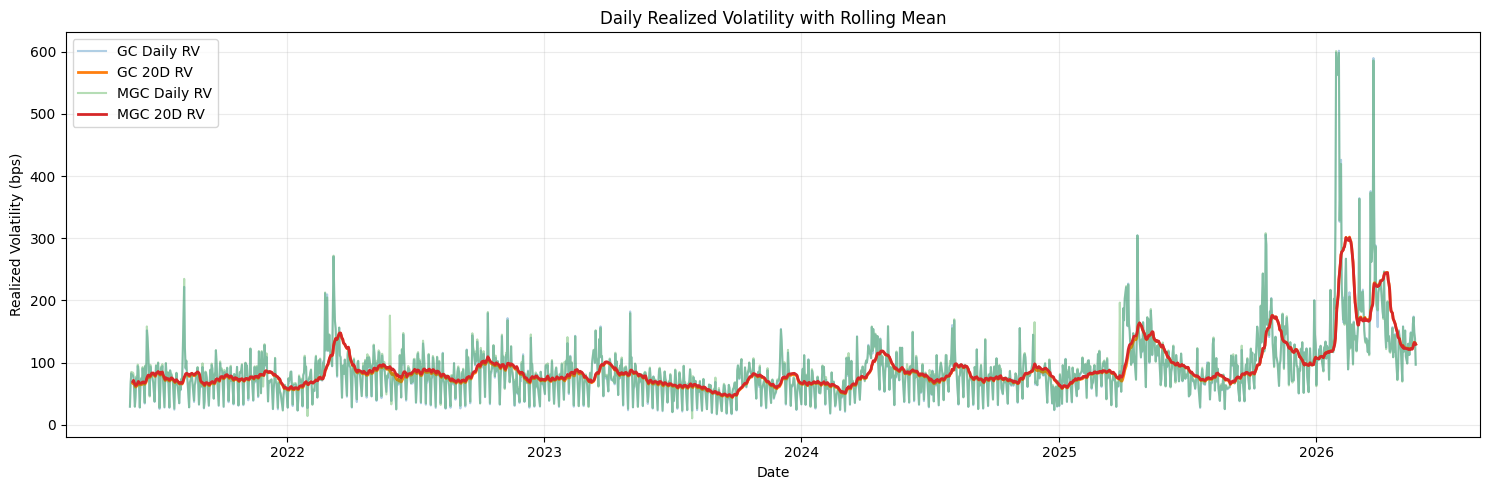

In [85]:
fig, ax = plt.subplots(figsize=(15, 5))

regime_colors = {
    "Low": "#4C78A8",
    "Normal": "#72B7B2",
    "High": "#F2CF5B",
    "Extreme": "#E45756",
}

for product, group in daily_volatility.groupby("product", observed=True):
    ax.plot(group["trade_date_ny"], group["realized_vol_bps"], alpha=0.35, label=f"{product} Daily RV")
    ax.plot(group["trade_date_ny"], group["rv_20d_mean"], linewidth=2, label=f"{product} 20D RV")

ax.set_title("Daily Realized Volatility with Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Realized Volatility (bps)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()


### 3.5.5 Volatility Clustering


In [86]:
# Volatility clustering check: autocorrelation of absolute/squared minute returns
# and daily realized volatility at multiple lags.
minute_lags = [1, 5, 15, 30, 60, 120]
daily_lags = [1, 2, 5, 10, 20]

clustering_rows = []
for product, group in returns.sort_values(["product", "ts_event"]).groupby("product", observed=True):
    abs_ret = group["abs_log_return"]
    sq_ret = group["squared_log_return"]
    for lag in minute_lags:
        clustering_rows.append({
            "product": product,
            "series": "minute_abs_return",
            "lag": lag,
            "autocorr": abs_ret.autocorr(lag=lag),
        })
        clustering_rows.append({
            "product": product,
            "series": "minute_squared_return",
            "lag": lag,
            "autocorr": sq_ret.autocorr(lag=lag),
        })

for product, group in daily_volatility.sort_values(["product", "trade_date_ny"]).groupby("product", observed=True):
    rv = group["realized_vol_bps"]
    for lag in daily_lags:
        clustering_rows.append({
            "product": product,
            "series": "daily_realized_vol",
            "lag": lag,
            "autocorr": rv.autocorr(lag=lag),
        })

volatility_clustering = pd.DataFrame(clustering_rows)
volatility_clustering


,product,series,lag,autocorr
0,GC,minute_abs_return,1,0.372699
1,GC,minute_squared_return,1,0.203841
2,GC,minute_abs_return,5,0.326397
3,GC,minute_squared_return,5,0.116411
4,GC,minute_abs_return,15,0.294703
5,GC,minute_squared_return,15,0.096800
6,GC,minute_abs_return,30,0.275573
7,GC,minute_squared_return,30,0.063302
8,GC,minute_abs_return,60,0.248650
9,GC,minute_squared_return,60,0.052144


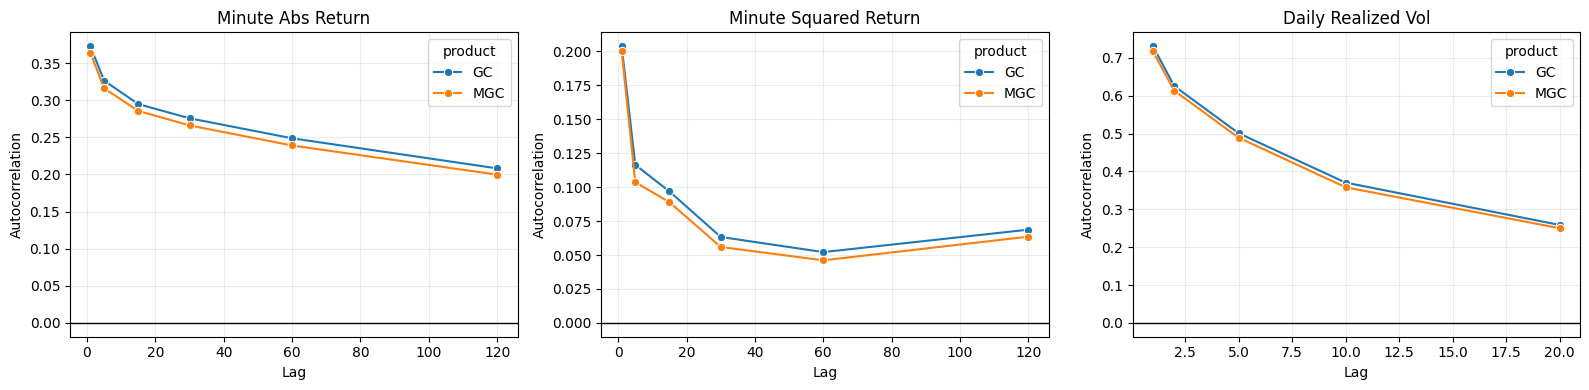

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, series_name in zip(axes, ["minute_abs_return", "minute_squared_return", "daily_realized_vol"]):
    plot_data = volatility_clustering[volatility_clustering["series"].eq(series_name)]
    sns.lineplot(data=plot_data, x="lag", y="autocorr", hue="product", marker="o", ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(series_name.replace("_", " ").title())
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.grid(alpha=0.25)

plt.tight_layout()


In [88]:
volatility_clustering_pivot = volatility_clustering.pivot_table(
    index=["series", "lag"],
    columns="product",
    values="autocorr",
)

volatility_clustering_pivot


product                          GC       MGC
series                lag                    
daily_realized_vol    1    0.730992  0.717328
                      2    0.625591  0.613472
                      5    0.501218  0.489429
                      10   0.370660  0.358248
                      20   0.258655  0.250127
minute_abs_return     1    0.372699  0.364108
                      5    0.326397  0.316009
                      15   0.294703  0.285542
                      30   0.275573  0.265980
                      60   0.248650  0.238941
                      120  0.208091  0.199658
minute_squared_return 1    0.203841  0.200414
                      5    0.116411  0.103605
                      15   0.096800  0.088868
                      30   0.063302  0.055909
                      60   0.052144  0.046083
                      120  0.068679  0.063536

**3.5 Volatility Analysis Notes**

* Volatility analysis uses the liquidity-selected active/front contract series from 3.4.
* 1-minute log returns are measured in basis points for readability.
* Intraday volatility is grouped into 30-minute New York-time buckets.
* Daily realized volatility is computed as the square root of summed 1-minute squared log returns.
* Volatility regimes are product-specific quartile/tail buckets, not absolute universal thresholds.
* Volatility clustering is checked through autocorrelation of absolute returns, squared returns, and daily realized volatility.

**Next:** 3.6 Return Analysis.


**3.5 Volatility Analysis**

**3.5.1 Return Distribution**

This section examines the distribution of **1-minute logarithmic returns** for the active/front-month contract series.

**Results**

```text
GC Observations:   1,763,129
MGC Observations:  1,730,486

GC Mean Return:    0.0038 bps
MGC Mean Return:   0.0039 bps

GC Standard Deviation:   3.078 bps
MGC Standard Deviation:  3.139 bps

GC Excess Kurtosis:  120.74
MGC Excess Kurtosis: 126.31
```

Both products exhibit average one-minute returns that are effectively zero, indicating no meaningful directional drift over short horizons. This is consistent with expectations for liquid financial markets.

The most significant finding is the extremely high excess kurtosis. A normal distribution has an excess kurtosis near zero, whereas both GC and MGC exceed 120, indicating exceptionally fat-tailed return distributions.

**Tail Risk Summary**

```text
GC
|Return| > 5 bps:   6.64%
|Return| > 10 bps:  1.24%
|Return| > 20 bps:  0.19%
|Return| > 50 bps:  0.012%

MGC
|Return| > 5 bps:   6.92%
|Return| > 10 bps:  1.28%
|Return| > 20 bps:  0.20%
|Return| > 50 bps:  0.013%
```

These results indicate that large price movements occur substantially more frequently than would be expected under a normal distribution.

**Conclusion**

Gold futures exhibit negligible short-term directional drift but possess extremely heavy-tailed return distributions. Consequently, future strategy development should avoid relying on normality assumptions and instead account explicitly for tail risk through robust risk management and volatility-aware modelling.

---

**3.5.2 Intraday Volatility**

Thirty-minute volatility profiles were constructed using New York trading hours.

The analysis indicates that volatility consistently peaks during the New York morning session, particularly between:

```text
08:00 – 11:00 New York Time
```

This period also corresponds to the highest levels of trading volume observed throughout the trading day.

Volatility therefore follows a pronounced intraday pattern rather than remaining constant across all trading sessions.

**Conclusion**

Intraday volatility is highly time-dependent. Signals generated during the New York morning should not be interpreted in the same manner as signals generated during quieter overnight periods. Future research should normalize returns by expected intraday volatility and incorporate session-aware volatility filters.

---

**3.5.3 Daily Volatility**

**Results**

```text
GC
Median Daily Realized Volatility:  80.52 bps
Mean Daily Realized Volatility:    89.69 bps
90th Percentile:                  136.75 bps
Maximum:                          601.68 bps

MGC
Median Daily Realized Volatility: 82.24 bps
Mean Daily Realized Volatility:   91.00 bps
90th Percentile:                 137.87 bps
Maximum:                         601.10 bps
```

Typical trading days exhibit realized volatility between approximately **80–90 basis points**, while the most volatile sessions exceed **600 basis points**.

Both GC and MGC display remarkably similar realized volatility characteristics throughout the sample period.

**Conclusion**

Daily realized volatility provides a useful baseline for distinguishing normal market conditions from unusually volatile trading sessions. These findings support volatility-adjusted position sizing and regime-based strategy evaluation rather than relying on fixed risk parameters.

---

**3.5.4 Volatility Regimes**

Daily realized volatility was divided into four product-specific regimes:

```text
Low:      Bottom 25%
Normal:   25% – 75%
High:     75% – 90%
Extreme:  Top 10%
```

**Extreme Volatility Results**

```text
GC Extreme Median Daily Volatility:  166.19 bps
MGC Extreme Median Daily Volatility: 169.35 bps
```

Extreme-volatility sessions exhibit approximately twice the realized volatility of a typical trading day and are accompanied by significantly larger price movements and increased trading activity.

**Conclusion**

Volatility regimes represent genuinely different market environments rather than arbitrary statistical groupings. Future strategy testing should evaluate performance separately across low, normal, high, and extreme volatility regimes to determine whether different trading approaches are better suited to different market conditions.

Potential applications include:

* Mean reversion during low-volatility environments.
* Momentum or breakout strategies during high-volatility environments.
* Volatility-adjusted position sizing.
* Regime-based trade filtering.

---

**3.5.5 Volatility Clustering**

**Daily Realized Volatility Autocorrelation**

```text
GC
Lag 1:   0.7310
Lag 5:   0.5012
Lag 20:  0.2587

MGC
Lag 1:   0.7173
Lag 5:   0.4894
Lag 20:  0.2501
```

**Minute-Level Absolute Return Autocorrelation**

```text
GC Lag 1:   0.3727
MGC Lag 1:  0.3641
```

Both products display strong positive volatility autocorrelation over multiple time horizons.

Periods of elevated volatility tend to be followed by further periods of elevated volatility, while calm market conditions similarly persist over time.

Importantly, although future price direction remains difficult to predict, volatility itself exhibits meaningful persistence.

**Conclusion**

Volatility clustering is one of the strongest empirical findings within the dataset. Recent realized volatility should therefore be incorporated as a predictive feature when constructing trading signals, selecting risk parameters, and adapting position sizing.

---

**3.5.6 Summary**

**Key Findings**

```text
Mean 1-Minute Returns:
Approximately 0 bps

Return Distributions:
Extremely fat-tailed

Typical Daily Realized Volatility:
80–90 bps

Highest Intraday Volatility:
08:00–11:00 New York Time

Extreme Volatility:
Approximately double normal daily volatility

Volatility Persistence:
Strong positive autocorrelation at both daily and minute horizons
```

**Overall Assessment**

The volatility analysis demonstrates that while short-term returns exhibit little directional bias, market volatility varies substantially across time and market conditions. Return distributions are characterized by significant tail risk, volatility follows a well-defined intraday pattern, and high-volatility environments tend to persist through time.

These findings establish volatility as a central component of future strategy development. Rather than treating volatility as background noise, subsequent research should explicitly incorporate volatility into signal generation, position sizing, stop-loss placement, take-profit calibration, and overall risk management.

Future signal evaluation should consistently consider the following questions before entering a trade:

* What volatility regime is currently active?
* Is volatility expanding or contracting?
* Is the observed move unusually large for the current time of day?
* Is the market operating under normal or extreme conditions?
* Should position sizing be adjusted?
* Should stop-loss and take-profit distances adapt to current volatility?

This analysis provides the statistical foundation for developing robust, volatility-aware systematic trading strategies.
